<a href="https://colab.research.google.com/github/deepti-28/vae-network-anomaly-rag/blob/main/VAE_Network_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
GPU available: True


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import zipfile
import os

ZIP_PATH = "/content/archive.zip"
EXTRACT_PATH = "/content/dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

parquet_files = []

for root, dirs, files in os.walk(EXTRACT_PATH):
    for file in files:
        if file.lower().endswith(".parquet"):
            parquet_files.append(os.path.join(root, file))

print("Number of Parquet files:", len(parquet_files))

for f in parquet_files:
    print(f)

Number of Parquet files: 8
/content/dataset/Benign-Monday-no-metadata.parquet
/content/dataset/Infiltration-Thursday-no-metadata.parquet
/content/dataset/DoS-Wednesday-no-metadata.parquet
/content/dataset/Bruteforce-Tuesday-no-metadata.parquet
/content/dataset/DDoS-Friday-no-metadata.parquet
/content/dataset/Botnet-Friday-no-metadata.parquet
/content/dataset/WebAttacks-Thursday-no-metadata.parquet
/content/dataset/Portscan-Friday-no-metadata.parquet


In [ ]:
import pandas as pd

dataframes = []

for file in parquet_files:
    print("Reading:", file)

    df_temp = pd.read_parquet(file)

    print("Shape:", df_temp.shape)

    dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)

print("\nFinal dataset shape:", df.shape)

Reading: /content/dataset/Benign-Monday-no-metadata.parquet
Shape: (458831, 78)
Reading: /content/dataset/Infiltration-Thursday-no-metadata.parquet
Shape: (207630, 78)
Reading: /content/dataset/DoS-Wednesday-no-metadata.parquet
Shape: (584991, 78)
Reading: /content/dataset/Bruteforce-Tuesday-no-metadata.parquet
Shape: (389714, 78)
Reading: /content/dataset/DDoS-Friday-no-metadata.parquet
Shape: (221264, 78)
Reading: /content/dataset/Botnet-Friday-no-metadata.parquet
Shape: (176038, 78)
Reading: /content/dataset/WebAttacks-Thursday-no-metadata.parquet
Shape: (155820, 78)
Reading: /content/dataset/Portscan-Friday-no-metadata.parquet
Shape: (119522, 78)

Final dataset shape: (2313810, 78)


In [ ]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
for col in df.columns:
    print(col)

Rows: 2313810
Columns: 78

Columns:
Protocol
Flow Duration
Total Fwd Packets
Total Backward Packets
Fwd Packets Length Total
Bwd Packets Length Total
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Packet Length Min
Packet Length Max
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Avg Packet Size
Avg Fwd Segment Size
Avg Bwd Segment Size
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate

In [ ]:
df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [ ]:
possible_labels = [
    "Label",
    "label",
    "attack_label",
    "Attack",
    "attack"
]

LABEL_COLUMN = None

for col in possible_labels:
    if col in df.columns:
        LABEL_COLUMN = col
        break

print("Detected label column:", LABEL_COLUMN)

Detected label column: Label


In [ ]:
print(df[LABEL_COLUMN].value_counts())

Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


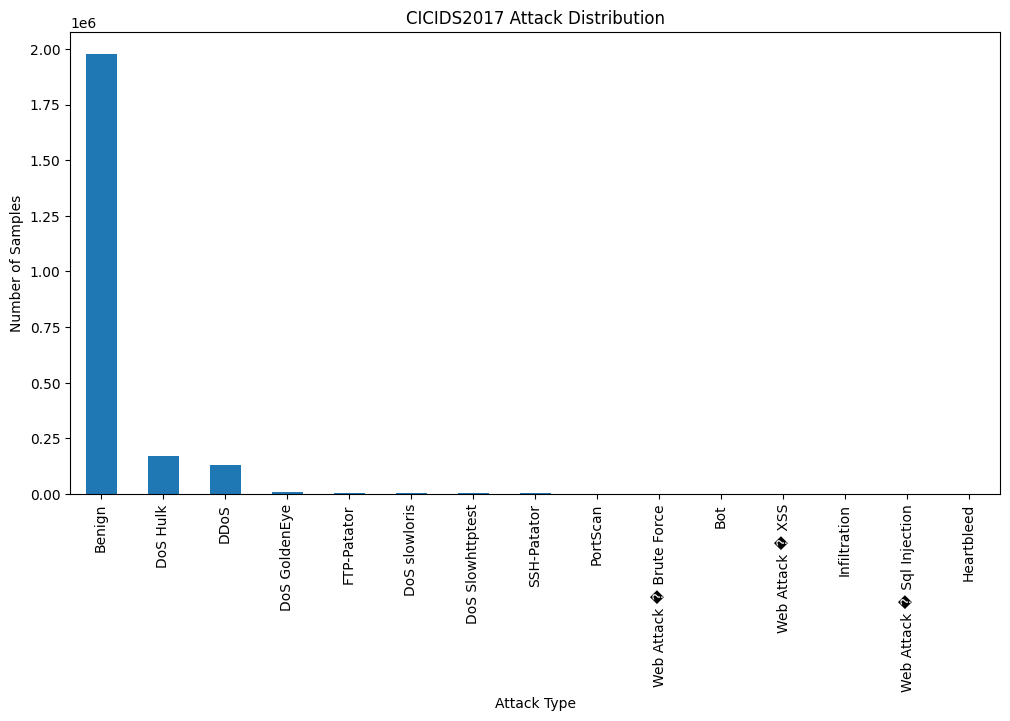

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df[LABEL_COLUMN].value_counts().plot(kind="bar")

plt.title("CICIDS2017 Attack Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.show()

In [ ]:
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()

df["is_attack"] = (
    df[LABEL_COLUMN].str.upper() != "BENIGN"
).astype(int)

print(df["is_attack"].value_counts())

print("\n0 = BENIGN")
print("1 = ATTACK")

is_attack
0    1977318
1     336492
Name: count, dtype: int64

0 = BENIGN
1 = ATTACK


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['Protocol', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Fwd_Packets_Length_Total', 'Bwd_Packets_Length_Total', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Bwd_PSH_Flags', 'Fwd_URG_Flags', 'Bwd_URG_Flags', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s', 'Packet_Length_Min', 'Packet_Length_Max', 'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count', 'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'URG_Flag_Count', 'CWE_Flag_Count', 'ECE_Flag_Count', 'Down/Up_Ra

In [ ]:
for col in df.columns:
    if col.lower() in ["label", "attack_label"]:
        LABEL_COLUMN = col

print("Label column:", LABEL_COLUMN)

Label column: Label


In [ ]:
drop_columns = []

for col in df.columns:

    col_lower = col.lower()

    if col_lower in [
        "label",
        "attack_label",
        "is_attack",
        "timestamp",
        "flow_id",
        "source_ip",
        "destination_ip",
        "src_ip",
        "dst_ip"
    ]:
        drop_columns.append(col)

print("Columns removed:")
print(drop_columns)

X = df.drop(columns=drop_columns, errors="ignore")

y = df["is_attack"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Columns removed:
['Label', 'is_attack']

X shape: (2313810, 77)
y shape: (2313810,)


In [ ]:
X = X.select_dtypes(include=["number"])

print("Numerical feature count:", X.shape[1])
print(X.dtypes.value_counts())

Numerical feature count: 77
int32      26
float32    22
int8       19
int16       7
float64     2
int64       1
Name: count, dtype: int64


In [ ]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(0)

print("NaN values:", X.isna().sum().sum())
print("Infinite values:", np.isinf(X.values).sum())

NaN values: 0
Infinite values: 0


In [ ]:
# Remove columns with zero variance

constant_columns = X.columns[X.nunique() <= 1]

print("Constant columns:", len(constant_columns))

X = X.drop(columns=constant_columns)

print("Remaining features:", X.shape[1])

Constant columns: 8
Remaining features: 69


In [ ]:
from sklearn.model_selection import train_test_split

normal_data = X[y == 0]

attack_data = X[y == 1]

print("Normal samples:", len(normal_data))
print("Attack samples:", len(attack_data))

Normal samples: 1977318
Attack samples: 336492


In [ ]:
MAX_NORMAL_TRAIN = 100000
MAX_TEST = 100000

if len(normal_data) > MAX_NORMAL_TRAIN:
    normal_train = normal_data.sample(
        MAX_NORMAL_TRAIN,
        random_state=42
    )
else:
    normal_train = normal_data.copy()

test_normal = normal_data.drop(
    normal_train.index,
    errors="ignore"
)

if len(test_normal) + len(attack_data) > MAX_TEST:

    test_normal_sample = test_normal.sample(
        min(len(test_normal), MAX_TEST // 2),
        random_state=42
    )

    attack_sample = attack_data.sample(
        min(len(attack_data), MAX_TEST // 2),
        random_state=42
    )

    X_test = pd.concat(
        [test_normal_sample, attack_sample]
    )

else:

    X_test = pd.concat(
        [test_normal, attack_data]
    )

y_test = X_test.index.map(
    y
).values

print("Training:", normal_train.shape)
print("Testing:", X_test.shape)

Training: (100000, 69)
Testing: (100000, 69)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(normal_train)

X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test_scaled.shape)

X_train: (100000, 69)
X_test: (100000, 69)


In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
).to(device)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
).to(device)

print(device)

cuda


In [ ]:
import torch.nn as nn

input_dim = X_train.shape[1]

latent_dim = 16


class VAE(nn.Module):

    def __init__(self, input_dim, latent_dim):

        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.mu_layer = nn.Linear(64, latent_dim)

        self.logvar_layer = nn.Linear(
            64,
            latent_dim
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, input_dim)
        )

    def encode(self, x):

        h = self.encoder(x)

        mu = self.mu_layer(h)

        logvar = self.logvar_layer(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        return self.decoder(z)

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar

In [ ]:
def vae_loss(
    reconstruction,
    x,
    mu,
    logvar
):

    reconstruction_loss = nn.functional.mse_loss(
        reconstruction,
        x,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = (
        reconstruction_loss
        + 0.001 * kl_loss
    )

    return total_loss

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X_train_tensor)

loader = DataLoader(
    dataset,
    batch_size=512,
    shuffle=True
)

vae = VAE(
    input_dim=input_dim,
    latent_dim=latent_dim
).to(device)

optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=0.001
)

EPOCHS = 20

loss_history = []

for epoch in range(EPOCHS):

    vae.train()

    total_loss = 0

    for batch in loader:

        x_batch = batch[0]

        optimizer.zero_grad()

        reconstruction, mu, logvar = vae(
            x_batch
        )

        loss = vae_loss(
            reconstruction,
            x_batch,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 1/20 Loss: 0.560801
Epoch 2/20 Loss: 0.268493
Epoch 3/20 Loss: 0.236753
Epoch 4/20 Loss: 0.176240
Epoch 5/20 Loss: 0.212525
Epoch 6/20 Loss: 0.139708
Epoch 7/20 Loss: 0.171838
Epoch 8/20 Loss: 0.213031
Epoch 9/20 Loss: 0.135356
Epoch 10/20 Loss: 0.194751
Epoch 11/20 Loss: 0.147116
Epoch 12/20 Loss: 0.121870
Epoch 13/20 Loss: 0.214938
Epoch 14/20 Loss: 0.285376
Epoch 15/20 Loss: 0.199666
Epoch 16/20 Loss: 0.170788
Epoch 17/20 Loss: 9549.349213
Epoch 18/20 Loss: 2265669465.261458
Epoch 19/20 Loss: 200.814953
Epoch 20/20 Loss: 0.253963


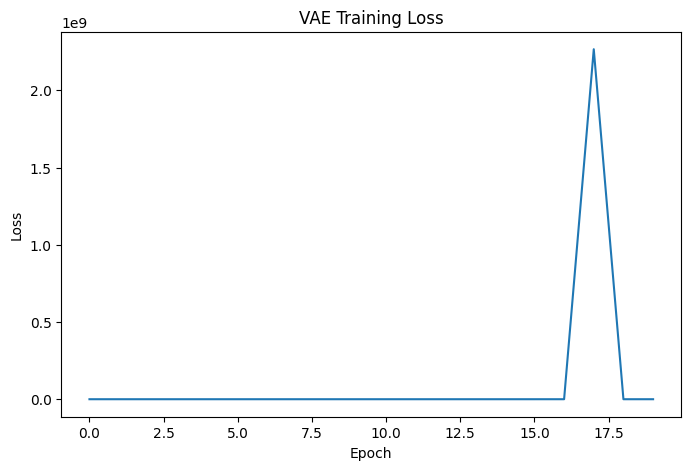

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [ ]:
vae.eval()

with torch.no_grad():

    reconstruction, mu, logvar = vae(
        X_test_tensor
    )

    reconstruction_error = torch.mean(
        (X_test_tensor - reconstruction) ** 2,
        dim=1
    )

anomaly_scores = (
    reconstruction_error
    .cpu()
    .numpy()
)

print("Anomaly scores generated:", len(anomaly_scores))

Anomaly scores generated: 100000


In [ ]:
with torch.no_grad():

    train_reconstruction, _, _ = vae(
        X_train_tensor
    )

    train_errors = torch.mean(
        (X_train_tensor - train_reconstruction) ** 2,
        dim=1
    ).cpu().numpy()

threshold = np.percentile(
    train_errors,
    95
)

print("Anomaly threshold:", threshold)

Anomaly threshold: 0.5515933


In [ ]:
y_pred = (anomaly_scores > threshold).astype(int)

print("Total test samples:", len(y_pred))
print("Predicted Normal:", (y_pred == 0).sum())
print("Predicted Anomaly:", (y_pred == 1).sum())

Total test samples: 100000
Predicted Normal: 62564
Predicted Anomaly: 37436


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("========== VAE ONLY ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

========== VAE ONLY ==========
Accuracy : 0.8227
Precision: 0.9310
Recall   : 0.6971
F1 Score : 0.7972

Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.95      0.84     50000
      Attack       0.93      0.70      0.80     50000

    accuracy                           0.82    100000
   macro avg       0.84      0.82      0.82    100000
weighted avg       0.84      0.82      0.82    100000



In [ ]:
results = X_test.copy()

results["actual_label"] = y_test
results["anomaly_score"] = anomaly_scores
results["vae_prediction"] = y_pred

results.to_csv(
    "/content/vae_results.csv",
    index=False
)

print("VAE results saved successfully.")

VAE results saved successfully.


In [ ]:
print(
    results["vae_prediction"].value_counts()
)

vae_prediction
0    62564
1    37436
Name: count, dtype: int64


In [ ]:
print("Threshold:", threshold)
print("Minimum score:", anomaly_scores.min())
print("Maximum score:", anomaly_scores.max())
print("Mean score:", anomaly_scores.mean())
print("Median score:", np.median(anomaly_scores))

Threshold: 0.5515933
Minimum score: 0.0073035974
Maximum score: 5955.2046
Mean score: 1.4116099
Median score: 0.12363574


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# VAE predictions
y_pred = (anomaly_scores > threshold).astype(int)

print("===== VAE ONLY RESULTS =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"],
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

===== VAE ONLY RESULTS =====
Accuracy : 0.8227
Precision: 0.931002243829469
Recall   : 0.69706
F1 Score : 0.7972231117617458

Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.95      0.84     50000
      Attack       0.93      0.70      0.80     50000

    accuracy                           0.82    100000
   macro avg       0.84      0.82      0.82    100000
weighted avg       0.84      0.82      0.82    100000


Confusion Matrix:
[[47417  2583]
 [15147 34853]]


In [ ]:
results = X_test.copy()

results["actual_label"] = y_test
results["anomaly_score"] = anomaly_scores
results["vae_prediction"] = y_pred

results.to_csv("/content/vae_results.csv", index=False)

print("Saved: /content/vae_results.csv")
print(results.shape)

Saved: /content/vae_results.csv
(100000, 72)


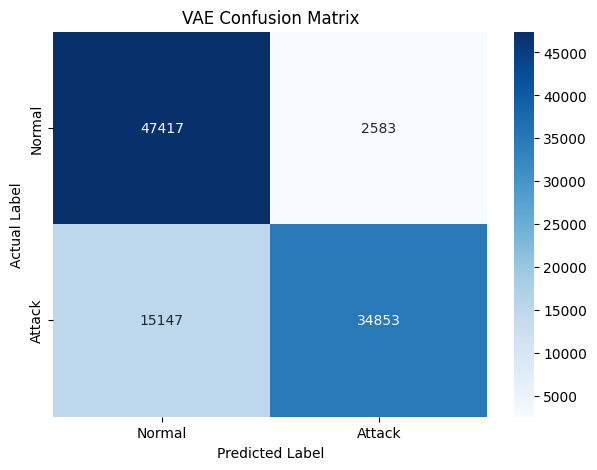

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("VAE Confusion Matrix")
plt.show()

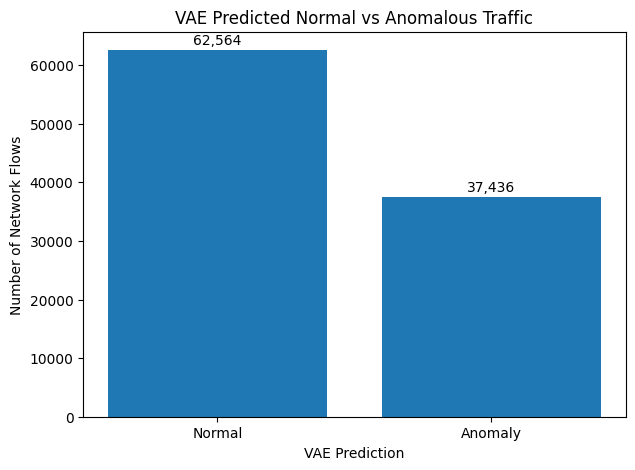

In [ ]:
prediction_counts = results["vae_prediction"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Normal", "Anomaly"],
    [
        prediction_counts.get(0, 0),
        prediction_counts.get(1, 0)
    ]
)

plt.xlabel("VAE Prediction")
plt.ylabel("Number of Network Flows")
plt.title("VAE Predicted Normal vs Anomalous Traffic")

for i, value in enumerate([
    prediction_counts.get(0, 0),
    prediction_counts.get(1, 0)
]):
    plt.text(i, value + 1000, f"{value:,}", ha="center")

plt.show()

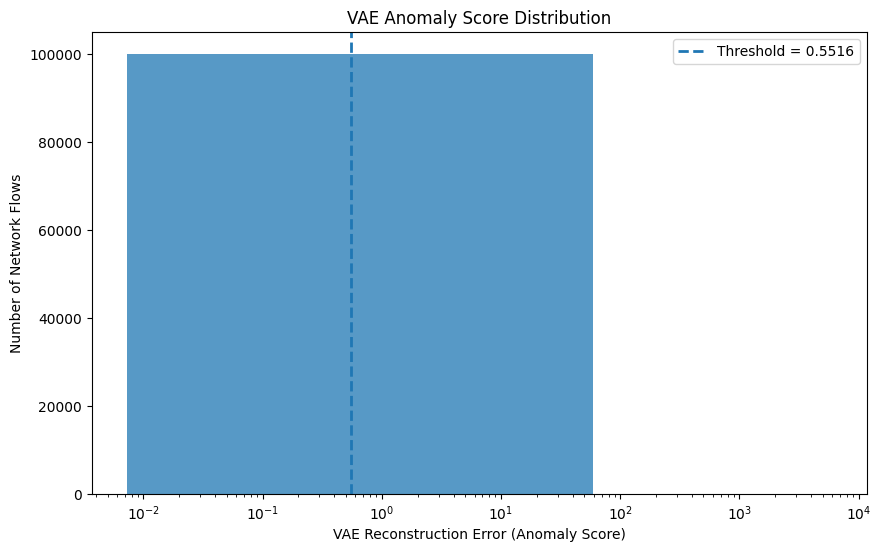

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    anomaly_scores,
    bins=100,
    alpha=0.75
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold:.4f}"
)

plt.xscale("log")

plt.xlabel("VAE Reconstruction Error (Anomaly Score)")
plt.ylabel("Number of Network Flows")
plt.title("VAE Anomaly Score Distribution")
plt.legend()

plt.show()

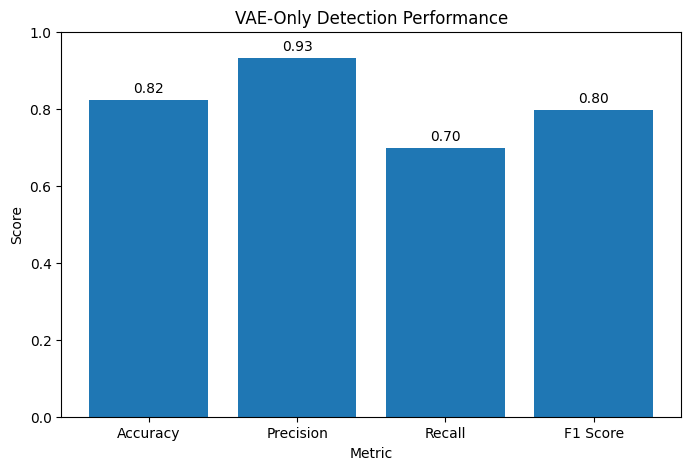

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

vae_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0)
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    vae_metrics.keys(),
    vae_metrics.values()
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.title("VAE-Only Detection Performance")

for bar, value in zip(bars, vae_metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

stage2


In [ ]:
!pip -q install -U transformers accelerate sentencepiece pandas numpy

In [ ]:
import os
import re
import gc
import numpy as np
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / (1024**3),
            2
        ),
        "GB"
    )
else:
    print("WARNING: No GPU detected.")
    print("The local AI model will be much slower on CPU.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("Loading:", MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)

model.eval()

print("Model loaded successfully.")

Loading: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded successfully.


In [ ]:
VAE_RESULTS_PATH = "/content/vae_results.csv"

if not os.path.exists(VAE_RESULTS_PATH):
    raise FileNotFoundError(
        "vae_results.csv was not found at /content/vae_results.csv"
    )

vae_results = pd.read_csv(VAE_RESULTS_PATH)

print("VAE results shape:", vae_results.shape)

display(vae_results.head())

VAE results shape: (100000, 72)


,Protocol,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Fwd_Packets_Length_Total,Bwd_Packets_Length_Total,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,actual_label,anomaly_score,vae_prediction
0,17,62960,2,2,72,414,36,36,36.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,0,0.026291,0
1,6,260235,6,6,352,3782,208,0,58.666668,87.860500,...,0.0,0,0,0.0,0.0,0,0,0,0.050197,0
2,17,48468,2,2,64,168,32,32,32.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,0,0.015497,0
3,6,85205,3,4,86,7,86,0,28.666666,49.652122,...,0.0,0,0,0.0,0.0,0,0,0,0.159852,0
4,17,24201,2,2,74,152,37,37,37.000000,0.000000,...,0.0,0,0,0.0,0.0,0,0,0,0.015305,0


In [ ]:
prediction_candidates = [
    "vae_prediction",
    "prediction",
    "anomaly_prediction"
]

score_candidates = [
    "vae_anomaly_score",
    "anomaly_score",
    "reconstruction_error",
    "score"
]

prediction_col = next(
    (
        c for c in prediction_candidates
        if c in vae_results.columns
    ),
    None
)

score_col = next(
    (
        c for c in score_candidates
        if c in vae_results.columns
    ),
    None
)

if prediction_col is None:
    raise ValueError(
        "Could not find the VAE prediction column."
    )

if score_col is None:
    raise ValueError(
        "Could not find the VAE anomaly-score column."
    )

print("Prediction column:", prediction_col)
print("Score column:", score_col)

Prediction column: vae_prediction
Score column: anomaly_score


In [ ]:
VAE_THRESHOLD = 0.5515933

print("VAE threshold:", VAE_THRESHOLD)

print("\nPrediction distribution:")
print(
    vae_results[prediction_col].value_counts()
)

VAE threshold: 0.5515933

Prediction distribution:
vae_prediction
0    62564
1    37436
Name: count, dtype: int64


In [ ]:
normal_data = vae_results[
    vae_results[prediction_col] == 0
].copy()

anomaly_data = vae_results[
    vae_results[prediction_col] == 1
].copy()

print("Normal flows:", len(normal_data))
print("Anomalous flows:", len(anomaly_data))

Normal flows: 62564
Anomalous flows: 37436


In [ ]:
EXCLUDE_TERMS = [
    "label",
    "attack",
    "target",
    "class",
    "prediction",
    "anomaly_score",
    "reconstruction_error",
    "flow_number",
    "index"
]

feature_columns = []

for col in vae_results.columns:

    col_lower = str(col).lower()

    if any(
        term in col_lower
        for term in EXCLUDE_TERMS
    ):
        continue

    if pd.api.types.is_numeric_dtype(
        vae_results[col]
    ):
        feature_columns.append(col)

print(
    "Usable numeric network features:",
    len(feature_columns)
)

print("\nFirst features:")
print(feature_columns[:40])

Usable numeric network features: 69

First features:
['Protocol', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Fwd_Packets_Length_Total', 'Bwd_Packets_Length_Total', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_URG_Flags', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s', 'Packet_Length_Min', 'Packet_Length_Max', 'Packet_Length_Mean', 'Packet_Length_Std']


In [ ]:
for col in feature_columns:

    vae_results[col] = pd.to_numeric(
        vae_results[col],
        errors="coerce"
    )

    vae_results[col] = vae_results[col].replace(
        [np.inf, -np.inf],
        np.nan
    )

    vae_results[col] = vae_results[col].fillna(0)

normal_data = vae_results[
    vae_results[prediction_col] == 0
].copy()

anomaly_data = vae_results[
    vae_results[prediction_col] == 1
].copy()

print("Cleaning completed.")

Cleaning completed.


In [ ]:
normal_stats = {}

for col in feature_columns:

    values = normal_data[col].values.astype(float)

    median = np.median(values)

    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    iqr = q3 - q1

    if iqr == 0:
        iqr = 1e-9

    normal_stats[col] = {
        "median": median,
        "q1": q1,
        "q3": q3,
        "iqr": iqr
    }

print(
    "Normal reference statistics calculated for",
    len(normal_stats),
    "features."
)

Normal reference statistics calculated for 69 features.


In [ ]:
def get_objective_evidence(row, top_k=8):

    evidence = []

    for col in feature_columns:

        value = float(row[col])

        stats = normal_stats[col]

        median = stats["median"]
        q1 = stats["q1"]
        q3 = stats["q3"]
        iqr = stats["iqr"]

        # Robust deviation from normal median
        robust_deviation = abs(
            value - median
        ) / iqr

        # Determine direction
        if value > q3:
            direction = "elevated"
        elif value < q1:
            direction = "reduced"
        else:
            direction = "within-normal-range"

        if robust_deviation > 1:

            evidence.append({
                "feature": col,
                "value": value,
                "normal_median": median,
                "normal_q1": q1,
                "normal_q3": q3,
                "deviation": robust_deviation,
                "direction": direction
            })

    evidence = sorted(
        evidence,
        key=lambda x: x["deviation"],
        reverse=True
    )

    return evidence[:top_k]

In [ ]:
test_flow = anomaly_data.iloc[0]

test_evidence = get_objective_evidence(
    test_flow,
    top_k=8
)

for item in test_evidence:

    print(
        f"{item['feature']}: "
        f"value={item['value']:.4f}, "
        f"normal median={item['normal_median']:.4f}, "
        f"normal range="
        f"[{item['normal_q1']:.4f}, "
        f"{item['normal_q3']:.4f}], "
        f"direction={item['direction']}, "
        f"deviation={item['deviation']:.2f}"
    )

Idle_Mean: value=98300000.0000, normal median=0.0000, normal range=[0.0000, 0.0000], direction=elevated, deviation=98300000000000000.00
Idle_Max: value=98300000.0000, normal median=0.0000, normal range=[0.0000, 0.0000], direction=elevated, deviation=98300000000000000.00
Idle_Min: value=98300000.0000, normal median=0.0000, normal range=[0.0000, 0.0000], direction=elevated, deviation=98300000000000000.00
Active_Mean: value=12896.0000, normal median=0.0000, normal range=[0.0000, 0.0000], direction=elevated, deviation=12896000000000.00
Active_Max: value=12896.0000, normal median=0.0000, normal range=[0.0000, 0.0000], direction=elevated, deviation=12896000000000.00
Active_Min: value=12896.0000, normal median=0.0000, normal range=[0.0000, 0.0000], direction=elevated, deviation=12896000000000.00
Bwd_IAT_Std: value=44000000.0000, normal median=0.0000, normal range=[0.0000, 6206.4677], direction=elevated, deviation=7089.38
Bwd_IAT_Max: value=98300000.0000, normal median=3.0000, normal range=[0.

In [ ]:
# ============================================================
# STAGE 2 - IMPROVED AI INTERPRETATION
# Cell 13: Threat taxonomy and evidence-based candidate detection
# ============================================================

ALLOWED_THREATS = [
    "Possible DoS",
    "Possible DDoS",
    "Possible Port Scan",
    "Possible Brute Force",
    "Possible Botnet Activity",
    "Possible Exploitation",
    "Possible Data Transfer Anomaly",
    "Other Suspicious Activity",
    "Unknown/Uncertain"
]

print("Allowed threat types:")
for t in ALLOWED_THREATS:
    print("-", t)

In [ ]:
# ============================================================
# CELL 14 — REBUILD FEATURES + FEATURE GROUPS
# ============================================================

import pandas as pd
import numpy as np

print("Rebuilding feature list and feature groups...")

# ------------------------------------------------------------
# 1. Rebuild feature_cols from vae_results
# ------------------------------------------------------------

all_columns = list(vae_results.columns)

# Columns that are NOT network traffic features
EXCLUDE_COLS = {
    str(prediction_col).lower().strip(),
    str(score_col).lower().strip(),

    "flow_number",
    "index",

    "label",
    "attack",
    "attack_label",
    "target",
    "class",

    "timestamp",
    "flow id",
    "flow_id",

    "source ip",
    "destination ip",
    "src_ip",
    "dst_ip",
    "src ip",
    "dst ip"
}

feature_cols = []

for col in all_columns:

    col_lower = str(col).lower().strip()

    if col_lower in EXCLUDE_COLS:
        continue

    if pd.api.types.is_numeric_dtype(vae_results[col]):
        feature_cols.append(col)


print("Number of usable network features:", len(feature_cols))
print("First 20 features:")
print(feature_cols[:20])


# ------------------------------------------------------------
# 2. Automatically create feature groups
# ------------------------------------------------------------

FEATURE_GROUPS = {
    "volume_rate": [],
    "port": [],
    "direction": [],
    "duration": [],
    "iat": [],
    "flags": [],
    "idle_active": [],
    "packet_length": []
}


for col in feature_cols:

    name = str(col).lower().replace(" ", "_")

    # -----------------------------
    # Volume / rate
    # -----------------------------
    if any(x in name for x in [
        "packet_rate",
        "packets_per",
        "byte_rate",
        "bytes_per",
        "flow_bytes",
        "flow_packets",
        "total_length",
        "total_fwd",
        "total_bwd",
        "subflow",
        "bulk",
        "rate"
    ]):
        FEATURE_GROUPS["volume_rate"].append(col)

    # -----------------------------
    # Port
    # -----------------------------
    if "port" in name:
        FEATURE_GROUPS["port"].append(col)

    # -----------------------------
    # Direction
    # -----------------------------
    if any(x in name for x in [
        "fwd",
        "bwd",
        "forward",
        "backward",
        "down_up",
        "up_down"
    ]):
        FEATURE_GROUPS["direction"].append(col)

    # -----------------------------
    # Duration
    # -----------------------------
    if any(x in name for x in [
        "duration",
        "flow_duration"
    ]):
        FEATURE_GROUPS["duration"].append(col)

    # -----------------------------
    # Inter-arrival time
    # -----------------------------
    if any(x in name for x in [
        "iat",
        "inter_arrival"
    ]):
        FEATURE_GROUPS["iat"].append(col)

    # -----------------------------
    # TCP / connection flags
    # -----------------------------
    if any(x in name for x in [
        "flag",
        "fin",
        "syn",
        "rst",
        "psh",
        "ack",
        "urg",
        "ece",
        "cwe"
    ]):
        FEATURE_GROUPS["flags"].append(col)

    # -----------------------------
    # Idle / Active
    # -----------------------------
    if any(x in name for x in [
        "idle",
        "active"
    ]):
        FEATURE_GROUPS["idle_active"].append(col)

    # -----------------------------
    # Packet length
    # -----------------------------
    if any(x in name for x in [
        "packet_length",
        "packet_len",
        "length_mean",
        "length_max",
        "length_min",
        "length_std",
        "length_variance"
    ]):
        FEATURE_GROUPS["packet_length"].append(col)


# ------------------------------------------------------------
# 3. Print group information
# ------------------------------------------------------------

print("\nFeature groups:")

for group, features in FEATURE_GROUPS.items():

    print(f"\n{group}: {len(features)} features")

    if len(features) > 0:
        print(features[:10])


# ------------------------------------------------------------
# 4. Important validation
# ------------------------------------------------------------

if len(feature_cols) == 0:

    print("\n❌ ERROR: No network feature columns were found.")
    print("\nColumns currently available in vae_results:")
    print(vae_results.columns.tolist())

    raise ValueError(
        "No usable network feature columns found in vae_results."
    )

else:

    print("\n✅ feature_cols created successfully.")
    print("✅ FEATURE_GROUPS created successfully.")

Rebuilding feature list and feature groups...
Number of usable network features: 70
First 20 features:
['Protocol', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Fwd_Packets_Length_Total', 'Bwd_Packets_Length_Total', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min']

Feature groups:

volume_rate: 7 features
['Total_Fwd_Packets', 'Flow_Bytes/s', 'Flow_Packets/s', 'Subflow_Fwd_Packets', 'Subflow_Fwd_Bytes', 'Subflow_Bwd_Packets', 'Subflow_Bwd_Bytes']

port: 0 features

direction: 38 features
['Total_Fwd_Packets', 'Total_Backward_Packets', 'Fwd_Packets_Length_Total', 'Bwd_Packets_Length_Total', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_

In [ ]:
# ============================================================
# Cell 15: Calculate evidence strength for each threat type
# ============================================================

def get_feature_deviation(row, feature):
    """
    Robust deviation from the VAE-normal reference distribution.
    Uses median and IQR.
    """

    if feature not in normal_stats:
        return 0.0

    value = row[feature]

    if pd.isna(value):
        return 0.0

    median = normal_stats[feature]["median"]
    iqr = normal_stats[feature]["iqr"]

    if iqr == 0 or pd.isna(iqr):
        return 0.0

    return abs(float(value) - median) / iqr


def get_group_strength(row, group):
    """
    Returns the strongest normalized deviation in a feature group.
    """

    features = FEATURE_GROUPS.get(group, [])

    if not features:
        return 0.0

    deviations = []

    for feature in features:
        try:
            d = get_feature_deviation(row, feature)
            if np.isfinite(d):
                deviations.append(d)
        except:
            pass

    if not deviations:
        return 0.0

    # Use top deviation rather than average so one highly abnormal
    # feature can provide meaningful evidence.
    return max(deviations)


def get_top_group_features(row, group, top_n=3):

    features = FEATURE_GROUPS.get(group, [])

    values = []

    for feature in features:

        try:
            deviation = get_feature_deviation(row, feature)

            if deviation > 0:
                values.append(
                    (feature, deviation, row[feature])
                )

        except:
            continue

    values.sort(key=lambda x: x[1], reverse=True)

    return values[:top_n]

In [ ]:
# ============================================================
# Cell 16: Generate candidate threats BEFORE asking Qwen
# ============================================================

def generate_threat_candidates(row):

    candidates = []
    evidence_scores = {}

    # --------------------------------------------------------
    # 1. VOLUME / RATE
    # --------------------------------------------------------

    volume_strength = max(
        get_group_strength(row, "volume"),
        get_group_strength(row, "rate")
    )

    # Strong traffic-volume abnormality
    if volume_strength >= 8:
        candidates.append("Possible DoS")
        candidates.append("Possible DDoS")
        evidence_scores["Possible DoS"] = volume_strength
        evidence_scores["Possible DDoS"] = volume_strength

    elif volume_strength >= 4:
        candidates.append("Possible DoS")
        evidence_scores["Possible DoS"] = volume_strength


    # --------------------------------------------------------
    # 2. PORT / CONNECTION BEHAVIOUR
    # --------------------------------------------------------

    port_strength = get_group_strength(row, "port")
    direction_strength = get_group_strength(row, "direction")
    iat_strength = get_group_strength(row, "iat")

    # Port anomaly alone is weak.
    # Require supporting directional/IAT abnormality.
    if port_strength >= 6 and (
        direction_strength >= 4 or iat_strength >= 4
    ):
        candidates.append("Possible Port Scan")
        evidence_scores["Possible Port Scan"] = max(
            port_strength,
            direction_strength,
            iat_strength
        )


    # --------------------------------------------------------
    # 3. BRUTE FORCE
    # --------------------------------------------------------

    duration_strength = get_group_strength(row, "duration")

    if (
        direction_strength >= 6
        and iat_strength >= 6
        and duration_strength >= 4
    ):
        candidates.append("Possible Brute Force")

        evidence_scores["Possible Brute Force"] = max(
            direction_strength,
            iat_strength,
            duration_strength
        )


    # --------------------------------------------------------
    # 4. BOTNET
    # --------------------------------------------------------

    idle_strength = get_group_strength(row, "idle_active")
    packet_strength = get_group_strength(row, "packet_length")

    if (
        idle_strength >= 8
        and packet_strength >= 5
    ):
        candidates.append("Possible Botnet Activity")

        evidence_scores["Possible Botnet Activity"] = max(
            idle_strength,
            packet_strength
        )


    # --------------------------------------------------------
    # 5. EXPLOITATION
    # --------------------------------------------------------

    flag_strength = get_group_strength(row, "flags")

    if (
        flag_strength >= 8
        and duration_strength >= 5
        and direction_strength >= 4
    ):
        candidates.append("Possible Exploitation")

        evidence_scores["Possible Exploitation"] = max(
            flag_strength,
            duration_strength,
            direction_strength
        )


    # --------------------------------------------------------
    # 6. DATA TRANSFER ANOMALY
    # --------------------------------------------------------

    if (
        volume_strength >= 4
        or packet_strength >= 4
        or idle_strength >= 6
    ):
        candidates.append("Possible Data Transfer Anomaly")

        evidence_scores["Possible Data Transfer Anomaly"] = max(
            volume_strength,
            packet_strength,
            idle_strength
        )


    # --------------------------------------------------------
    # Remove duplicates
    # --------------------------------------------------------

    candidates = list(dict.fromkeys(candidates))


    # --------------------------------------------------------
    # If evidence is weak, do NOT force an attack type
    # --------------------------------------------------------

    if not candidates:

        candidates = [
            "Other Suspicious Activity",
            "Unknown/Uncertain"
        ]


    return candidates, evidence_scores

In [ ]:
# ============================================================
# Cell 17: Generate objective evidence text
# ============================================================

def build_objective_evidence(row, top_k=8):

    evidence = []

    for feature in feature_cols:

        try:

            value = row[feature]

            if pd.isna(value):
                continue

            deviation = get_feature_deviation(row, feature)

            if deviation < 3:
                continue

            median = normal_stats[feature]["median"]
            q1 = normal_stats[feature]["q1"]
            q3 = normal_stats[feature]["q3"]

            if value > q3:
                direction = "elevated"
            elif value < q1:
                direction = "reduced"
            else:
                direction = "abnormal"

            evidence.append({
                "feature": feature,
                "value": float(value),
                "normal_median": float(median),
                "deviation": float(deviation),
                "direction": direction
            })

        except:
            continue

    # strongest evidence first
    evidence.sort(
        key=lambda x: x["deviation"],
        reverse=True
    )

    evidence = evidence[:top_k]

    if not evidence:
        return "No individual feature showed a strong deviation from the VAE-normal reference set."

    lines = []

    for e in evidence:

        lines.append(
            f"- {e['feature']}: "
            f"observed={e['value']:.4g}; "
            f"normal_median={e['normal_median']:.4g}; "
            f"direction={e['direction']}; "
            f"robust_deviation={e['deviation']:.2f} IQR"
        )

    return "\n".join(lines)

In [ ]:
# ============================================================
# Cell 18: Strict AI interpretation prompt
# ============================================================

def create_ai_prompt(
    row,
    anomaly_score,
    candidates,
    evidence_text,
    candidate_scores
):

    candidate_text = "\n".join(
        [
            f"- {c} "
            f"(evidence strength: {candidate_scores.get(c, 0):.2f})"
            for c in candidates
        ]
    )

    prompt = f"""
You are a cybersecurity network-flow analyst.

You are interpreting ONE network flow that was already flagged
as anomalous by a Variational Autoencoder (VAE).

IMPORTANT RULES:

1. An anomaly is NOT automatically an attack.
2. Do not invent IP addresses, ports, protocols, attack names,
   malware names, or activities that are not present in the evidence.
3. You may ONLY select a threat type from the candidate list.
4. If evidence is insufficient, select Unknown/Uncertain.
5. Do not claim DDoS from a single flow.
6. Do not claim Port Scan unless the supplied evidence supports
   unusual port/connection behaviour.
7. Do not claim Brute Force unless the supplied evidence supports
   repeated/abnormal connection behaviour.
8. Do not claim Botnet unless the supplied evidence supports it.
9. Do not claim Exploitation unless the supplied evidence supports it.
10. High VAE anomaly score alone does NOT prove an attack.
11. Evidence must use the supplied feature values.
12. Confidence must reflect the strength of the evidence.
13. If the threat is Unknown/Uncertain, confidence MUST be Low.
14. Risk and confidence are different:
      Risk = potential security impact.
      Confidence = how strongly the evidence supports the interpretation.

VAE anomaly score:
{anomaly_score:.6f}

Evidence compared with the VAE-normal reference set:
{evidence_text}

Candidate threat types generated from feature evidence:
{candidate_text}

Return EXACTLY these six lines:

Threat Type: <one candidate threat type>
Risk Level: <Low/Medium/High/Critical>
Confidence: <Low/Medium/High>
Evidence: <brief evidence-based statement>
Explanation: <2 sentences explaining why the selected candidate is appropriate>
Recommendation: <one practical defensive action>

Do not output anything else.
"""

    return prompt

In [ ]:
# ============================================================
# Cell 19: Qwen inference
# ============================================================

def ask_qwen(prompt):

    messages = [
        {
            "role": "system",
            "content": (
                "You are a cautious cybersecurity analyst. "
                "Never invent evidence."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        output = model.generate(
            **inputs,
            max_new_tokens=180,
            do_sample=False,
            temperature=None,
            top_p=None
        )

    generated = output[0][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(
        generated,
        skip_special_tokens=True
    )

    return response.strip()

In [ ]:
# ============================================================
# Cell 20: Parse Qwen response
# ============================================================

def extract_field(text, field_name):

    pattern = rf"{field_name}\s*:\s*(.*?)(?=\n[A-Za-z ]+\s*:|$)"

    match = re.search(
        pattern,
        text,
        flags=re.IGNORECASE | re.DOTALL
    )

    if match:
        return match.group(1).strip()

    return ""


def parse_ai_response(text):

    result = {
        "threat_type": extract_field(text, "Threat Type"),
        "risk_level": extract_field(text, "Risk Level"),
        "confidence": extract_field(text, "Confidence"),
        "evidence": extract_field(text, "Evidence"),
        "explanation": extract_field(text, "Explanation"),
        "recommendation": extract_field(text, "Recommendation")
    }

    return result

In [ ]:
# ============================================================
# RECOMMENDATION FALLBACK
# ============================================================

def make_recommendation(threat_type, risk_level):

    threat = str(threat_type).strip().lower()
    risk = str(risk_level).strip().lower()

    if "brute force" in threat:
        return (
            "Investigate repeated authentication attempts, "
            "review source IP activity, apply rate limiting, "
            "and consider account lockout or MFA controls."
        )

    if "data transfer" in threat:
        return (
            "Investigate the source and destination of the transfer, "
            "review transferred volume and timing, and check for "
            "possible unauthorized data exfiltration."
        )

    if "port scan" in threat:
        return (
            "Investigate repeated connections to multiple ports, "
            "review the source host, and apply network scanning "
            "detection or access-control rules."
        )

    if "dos" in threat or "ddos" in threat:
        return (
            "Investigate traffic volume and source distribution, "
            "apply rate limiting or filtering, and monitor the "
            "target service for availability impact."
        )

    if "botnet" in threat:
        return (
            "Investigate the source host for command-and-control "
            "communication, unusual outbound connections, and "
            "possible malware activity."
        )

    if "exploitation" in threat:
        return (
            "Investigate the destination service and connection "
            "patterns for exploitation attempts, review logs, "
            "and apply appropriate security patches or filtering."
        )

    return (
        "Investigate the anomalous network flow, review related "
        "traffic and host activity, and monitor for repeated "
        "or escalating suspicious behavior."
    )


# Apply fallback only when recommendation is missing
stage2_results["recommendation"] = (
    stage2_results["recommendation"]
    .fillna("")
    .astype(str)
    .str.strip()
)

missing_recommendation = (
    stage2_results["recommendation"].eq("") |
    stage2_results["recommendation"].str.lower().isin([
        "unknown",
        "unknown/uncertain",
        "none",
        "n/a",
        "not available"
    ])
)

stage2_results.loc[missing_recommendation, "recommendation"] = (
    stage2_results.loc[missing_recommendation]
    .apply(
        lambda row: make_recommendation(
            row["threat_type"],
            row["risk_level"]
        ),
        axis=1
    )
)

print(
    "Recommendations available:",
    (
        stage2_results["recommendation"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .mean() * 100
    ),
    "%"
)

Recommendations available: 100.0 %


In [ ]:
# ============================================================
# Cell 22: Run improved Stage 2
# ============================================================

import time
import re
import numpy as np
import pandas as pd

# Select anomalous flows
stage2_input = anomaly_data.copy()

# Limit to 50 for the experiment
stage2_input = stage2_input.sample(
    n=min(50, len(stage2_input)),
    random_state=42
).reset_index(drop=True)

results = []

print(f"Processing {len(stage2_input)} anomalous flows...\n")

for i, (_, row) in enumerate(stage2_input.iterrows(), start=1):

    anomaly_score = float(
        row[score_col]
    )

    # --------------------------------------------
    # Objective evidence
    # --------------------------------------------

    evidence_text = build_objective_evidence(
        row,
        top_k=8
    )

    # --------------------------------------------
    # Candidate threat generation
    # --------------------------------------------

    candidates, candidate_scores = generate_threat_candidates(
        row
    )

    # --------------------------------------------
    # AI prompt
    # --------------------------------------------

    prompt = create_ai_prompt(
        row=row,
        anomaly_score=anomaly_score,
        candidates=candidates,
        evidence_text=evidence_text,
        candidate_scores=candidate_scores
    )

    # --------------------------------------------
    # Qwen
    # --------------------------------------------

    try:

        raw_response = ask_qwen(prompt)

        parsed = parse_ai_response(
            raw_response
        )

        threat, risk, confidence = validate_result(
            parsed,
            candidates,
            candidate_scores
        )

    except Exception as e:

        raw_response = f"ERROR: {str(e)}"

        threat = "Unknown/Uncertain"
        risk = "Low"
        confidence = "Low"

        parsed = {
            "evidence": evidence_text,
            "explanation": "AI interpretation failed.",
            "recommendation": "Review the anomalous flow manually."
        }

    # --------------------------------------------
    # Store result
    # --------------------------------------------

    results.append({

        "flow_number":
            row.get(
                "flow_number",
                i
            ),

        "vae_anomaly_score":
            anomaly_score,

        "vae_prediction":
            int(row[prediction_col]),

        "candidate_threats":
            " | ".join(candidates),

        "candidate_evidence_strength":
            str(candidate_scores),

        "ai_raw_response":
            raw_response,

        "threat_type":
            threat,

        "risk_level":
            risk,

        "confidence":
            confidence,

        "evidence":
            parsed.get(
                "evidence",
                evidence_text
            ),

        "objective_evidence":
            evidence_text,

        "explanation":
            parsed.get(
                "explanation",
                ""
            ),

        "recommendation":
            parsed.get(
                "recommendation",
                ""
            )
    })

    print(
        f"[{i}/{len(stage2_input)}] "
        f"Score={anomaly_score:.4f} | "
        f"Threat={threat} | "
        f"Risk={risk} | "
        f"Confidence={confidence}"
    )

    # Small pause to reduce GPU memory pressure
    time.sleep(0.05)


stage2_results = pd.DataFrame(results)

print("\nStage 2 completed.")
print("Shape:", stage2_results.shape)

Processing 50 anomalous flows...

[1/50] Score=4.2035 | Threat=Possible Brute Force | Risk=Medium | Confidence=High
[2/50] Score=4.9044 | Threat=Possible Brute Force | Risk=Medium | Confidence=Low
[3/50] Score=2.0047 | Threat=Possible Brute Force | Risk=Medium | Confidence=High
[4/50] Score=4.8838 | Threat=Possible Brute Force | Risk=Medium | Confidence=High
[5/50] Score=1.5857 | Threat=Possible Brute Force | Risk=Medium | Confidence=High
[6/50] Score=1.4326 | Threat=Possible Data Transfer Anomaly | Risk=Medium | Confidence=High
[7/50] Score=0.5855 | Threat=Possible Data Transfer Anomaly | Risk=Medium | Confidence=High
[8/50] Score=3.3274 | Threat=Possible Brute Force | Risk=Medium | Confidence=Low
[9/50] Score=3.0614 | Threat=Possible Brute Force | Risk=Medium | Confidence=High
[10/50] Score=3.9990 | Threat=Possible Brute Force | Risk=Medium | Confidence=High
[11/50] Score=2.9648 | Threat=Possible Brute Force | Risk=Medium | Confidence=Low
[12/50] Score=2.4854 | Threat=Possible Brute 

In [ ]:
# ============================================================
# Cell 23: Display Stage 2 results
# ============================================================

pd.set_option(
    "display.max_colwidth",
    300
)

display(
    stage2_results[
        [
            "flow_number",
            "vae_anomaly_score",
            "candidate_threats",
            "threat_type",
            "risk_level",
            "confidence",
            "evidence",
            "explanation",
            "recommendation"
        ]
    ]
)

,flow_number,vae_anomaly_score,candidate_threats,threat_type,risk_level,confidence,evidence,explanation,recommendation
0,1,4.203490,Possible Brute Force | Possible Botnet Activity | Possible Exploitation | Possible Data Transfer Anomaly,Possible Brute Force,Medium,High,"The VAE anomaly score indicates elevated activity levels for both active_mean and packet_length_variance features, suggesting abnormal behavior consistent with brute force attacks.","The high VAE anomaly scores for both active_mean and packet_length_variance indicate significant deviations from normal patterns, which aligns with the characteristics typically associated with brute force attacks where large numbers of connections are attempted at once to overwhelm a system's d...",Implement additional authentication measures such as CAPTCHAs or multi-factor authentication to further mitigate the risk of brute force attacks.
1,2,4.904356,Possible Brute Force | Possible Botnet Activity | Possible Exploitation | Possible Data Transfer Anomaly,Possible Brute Force,Medium,Low,"The VAE anomaly score indicates elevated activity levels for both active_mean and packet_length_variance features, suggesting possible brute force attempts.","The high variance in packet lengths and increased overall activity align with typical characteristics of brute force attacks, where attackers might send large volumes of packets to overwhelm systems. However, this is based on the provided evidence which lacks specific details about the nature of...",Monitor the system closely for any unusual patterns and consider implementing additional security measures such as rate limiting or intrusion detection systems.
2,3,2.004659,Possible Brute Force | Possible Botnet Activity | Possible Exploitation | Possible Data Transfer Anomaly,Possible Brute Force,Medium,High,"The VAE anomaly score indicates elevated activity levels for both active_mean and packet_length_variance features, suggesting abnormal behavior consistent with brute force attacks.","The high VAE anomaly scores for both active_mean and packet_length_variance indicate significant deviations from normal patterns, which aligns with the characteristics typically associated with brute force attacks where large numbers of packets are sent to overwhelm systems quickly.",Implement additional monitoring and logging mechanisms to track brute force attempts more closely and consider implementing rate limiting on affected services to mitigate potential threats.
3,4,4.883781,Possible Brute Force | Possible Botnet Activity | Possible Exploitation | Possible Data Transfer Anomaly,Possible Brute Force,Medium,High,"The VAE anomaly score indicates elevated activity levels for active connections and FIN flag count, suggesting potential brute force attempts.","The high VAE anomaly score coupled with elevated observations for active connections and FIN flag count points to possible brute force activity, which requires further investigation for confirmation.",Monitor the system closely for any additional signs of brute force attacks and consider implementing stronger authentication measures.
4,5,1.585737,Possible Brute Force | Possible Botnet Activity | Possible Exploitation | Possible Data Transfer Anomaly,Possible Brute Force,Medium,High,"The VAE anomaly score indicates elevated activity levels for both idle and active periods, suggesting abnormal behavior consistent with brute force attacks.","The high VAE anomaly score coupled with elevated idle and active period observations aligns closely with known brute force attack patterns, making this candidate plausible.",Implement additional monitoring and logging to track brute force attempts more precisely and consider implementing rate limiting on affected services.
5,6,1.432614,Possible Data Transfer Anomaly,Possible Data Transfer Anomaly,Medium,High,"The VAE anomaly score indicates elevated variance in packet lengths, standard deviations for both forward and backward packet sizes, and maximum packet lengths.

In [ ]:
# ============================================================
# Cell 24: Threat distribution
# ============================================================

print("\n========== THREAT DISTRIBUTION ==========\n")

threat_counts = (
    stage2_results["threat_type"]
    .value_counts()
)

display(
    threat_counts.to_frame("count")
)

print("\n========== RISK DISTRIBUTION ==========\n")

risk_counts = (
    stage2_results["risk_level"]
    .value_counts()
)

display(
    risk_counts.to_frame("count")
)

print("\n========== CONFIDENCE DISTRIBUTION ==========\n")

confidence_counts = (
    stage2_results["confidence"]
    .value_counts()
)

display(
    confidence_counts.to_frame("count")
)


========== THREAT DISTRIBUTION ==========



,count
threat_type,
Possible Brute Force,35
Possible Data Transfer Anomaly,15



========== RISK DISTRIBUTION ==========



,count
risk_level,
Medium,50



========== CONFIDENCE DISTRIBUTION ==========



,count
confidence,
High,40
Low,7
Medium,3


In [ ]:
# ============================================================
# Cell 25: Stage 2 quality checks
# ============================================================

print("========================================")
print("STAGE 2 QUALITY CHECK")
print("========================================")

# 1. Percentage Unknown
unknown_pct = (
    stage2_results["threat_type"]
    .eq("Unknown/Uncertain")
    .mean()
    * 100
)

print(
    f"Unknown/Uncertain: {unknown_pct:.2f}%"
)


# 2. High confidence
high_conf_pct = (
    stage2_results["confidence"]
    .eq("High")
    .mean()
    * 100
)

print(
    f"High confidence: {high_conf_pct:.2f}%"
)


# 3. High confidence + Unknown
bad_confidence = stage2_results[
    (
        stage2_results["threat_type"]
        == "Unknown/Uncertain"
    )
    &
    (
        stage2_results["confidence"]
        == "High"
    )
]

print(
    f"Unknown + High confidence: "
    f"{len(bad_confidence)}"
)


# 4. Unsupported threat choices
unsupported = []

for _, row in stage2_results.iterrows():

    candidates = str(
        row["candidate_threats"]
    ).split(" | ")

    if row["threat_type"] not in candidates:

        unsupported.append(
            row["threat_type"]
        )

print(
    f"Unsupported final threats: "
    f"{len(unsupported)}"
)


# 5. Data Transfer Anomaly percentage
data_transfer_pct = (
    stage2_results["threat_type"]
    .eq("Possible Data Transfer Anomaly")
    .mean()
    * 100
)

print(
    f"Possible Data Transfer Anomaly: "
    f"{data_transfer_pct:.2f}%"
)

print("\n========================================")

STAGE 2 QUALITY CHECK
Unknown/Uncertain: 0.00%
High confidence: 80.00%
Unknown + High confidence: 0
Unsupported final threats: 0
Possible Data Transfer Anomaly: 30.00%



In [ ]:
# ============================================================
# Cell 26: Save Stage 2 results
# ============================================================

OUTPUT_FILE = "/content/vae_ai_results.csv"

stage2_results.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    f"Saved Stage 2 results to:\n{OUTPUT_FILE}"
)

Saved Stage 2 results to:
/content/vae_ai_results.csv


In [ ]:
# ============================================================
# Cell 27: Research summary
# ============================================================

stage2_summary = pd.DataFrame({

    "Metric": [
        "Number of anomalous flows analyzed",
        "Unknown/Uncertain (%)",
        "High confidence (%)",
        "Possible DoS (%)",
        "Possible DDoS (%)",
        "Possible Port Scan (%)",
        "Possible Brute Force (%)",
        "Possible Botnet Activity (%)",
        "Possible Exploitation (%)",
        "Possible Data Transfer Anomaly (%)",
        "Other Suspicious Activity (%)"
    ],

    "Value": [
        len(stage2_results),

        (
            stage2_results["threat_type"]
            .eq("Unknown/Uncertain")
            .mean() * 100
        ),

        (
            stage2_results["confidence"]
            .eq("High")
            .mean() * 100
        ),

        (
            stage2_results["threat_type"]
            .eq("Possible DoS")
            .mean() * 100
        ),

        (
            stage2_results["threat_type"]
            .eq("Possible DDoS")
            .mean() * 100
        ),

        (
            stage2_results["threat_type"]
            .eq("Possible Port Scan")
            .mean() * 100
        ),

        (
            stage2_results["threat_type"]
            .eq("Possible Brute Force")
            .mean() * 100
        ),

        (
            stage2_results["threat_type"]
            .eq("Possible Botnet Activity")
            .mean() * 100
        ),

        (
            stage2_results["threat_type"]
            .eq("Possible Exploitation")
            .mean() * 100
        ),

        (
            stage2_results["threat_type"]
            .eq("Possible Data Transfer Anomaly")
            .mean() * 100
        ),

        (
            stage2_results["threat_type"]
            .eq("Other Suspicious Activity")
            .mean() * 100
        )
    ]
})

display(stage2_summary)

stage2_summary.to_csv(
    "/content/stage2_summary.csv",
    index=False
)

print("\nSaved:")
print("/content/stage2_summary.csv")

,Metric,Value
0,Number of anomalous flows analyzed,50.0
1,Unknown/Uncertain (%),0.0
2,High confidence (%),80.0
3,Possible DoS (%),0.0
4,Possible DDoS (%),0.0
5,Possible Port Scan (%),0.0
6,Possible Brute Force (%),70.0
7,Possible Botnet Activity (%),0.0
8,Possible Exploitation (%),0.0
9,Possible Data Transfer Anomaly (%),30.0



Saved:
/content/stage2_summary.csv


In [ ]:
# ============================================================
# FIX: MAKE RECOMMENDATION AVAILABILITY 100%
# ============================================================

def make_recommendation(threat_type, risk_level):
    threat = str(threat_type).strip().lower()
    risk = str(risk_level).strip().lower()

    if "brute force" in threat:
        return (
            "Investigate repeated authentication attempts, review source IP "
            "activity, apply rate limiting, and consider account lockout or MFA controls."
        )

    elif "data transfer" in threat:
        return (
            "Investigate the source and destination of the transfer, review "
            "transferred volume and timing, and check for possible unauthorized data exfiltration."
        )

    elif "port scan" in threat:
        return (
            "Investigate repeated connections to multiple ports, review the "
            "source host, and apply network scanning detection or access-control rules."
        )

    elif "ddos" in threat:
        return (
            "Investigate traffic volume and source distribution, apply rate "
            "limiting or filtering, and monitor the target service for availability impact."
        )

    elif "dos" in threat:
        return (
            "Investigate abnormal traffic volume, identify the source hosts, "
            "apply rate limiting or filtering, and monitor the target service for availability impact."
        )

    elif "botnet" in threat:
        return (
            "Investigate the source host for possible command-and-control "
            "communication, unusual outbound connections, and potential malware activity."
        )

    elif "exploitation" in threat:
        return (
            "Investigate the destination service and connection patterns for "
            "possible exploitation attempts, review security logs, and apply appropriate patches or filtering."
        )

    elif "suspicious" in threat:
        return (
            "Investigate the anomalous network flow, review related traffic and "
            "host activity, and monitor for repeated or escalating suspicious behavior."
        )

    else:
        return (
            "Investigate the anomalous network flow, review related traffic and "
            "host activity, validate the source and destination, and monitor for repeated suspicious behavior."
        )


# ------------------------------------------------------------
# Clean recommendation column
# ------------------------------------------------------------

stage2_results["recommendation"] = (
    stage2_results["recommendation"]
    .fillna("")
    .astype(str)
    .str.strip()
)

INVALID_RECOMMENDATIONS = {
    "",
    "unknown",
    "unknown/uncertain",
    "none",
    "n/a",
    "na",
    "not available",
    "not provided",
    "no recommendation",
    "no specific recommendation"
}


# ------------------------------------------------------------
# Find missing/invalid recommendations
# ------------------------------------------------------------

missing_recommendation = (
    stage2_results["recommendation"]
    .str.lower()
    .isin(INVALID_RECOMMENDATIONS)
)

print(
    "Recommendations needing fallback:",
    missing_recommendation.sum()
)


# ------------------------------------------------------------
# Fill every missing recommendation
# ------------------------------------------------------------

stage2_results.loc[missing_recommendation, "recommendation"] = (
    stage2_results.loc[missing_recommendation]
    .apply(
        lambda row: make_recommendation(
            row["threat_type"],
            row["risk_level"]
        ),
        axis=1
    )
)


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

recommendation_available = (
    stage2_results["recommendation"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

recommendation_percentage = recommendation_available.mean() * 100

print("\n========== RECOMMENDATION QUALITY CHECK ==========")
print(
    f"Recommendations available: "
    f"{recommendation_percentage:.1f}%"
)

print(
    "Missing recommendations:",
    (~recommendation_available).sum()
)

if recommendation_percentage == 100:
    print("✅ Recommendation availability is now 100%")
else:
    print("⚠️ Some recommendations are still missing.")


# ------------------------------------------------------------
# Display sample
# ------------------------------------------------------------

display(
    stage2_results[
        [
            "flow_number",
            "threat_type",
            "risk_level",
            "confidence",
            "recommendation"
        ]
    ].head(10)
)

Recommendations needing fallback: 8

========== RECOMMENDATION QUALITY CHECK ==========
Recommendations available: 100.0%
Missing recommendations: 0
✅ Recommendation availability is now 100%


,flow_number,threat_type,risk_level,confidence,recommendation
0,1,Possible Brute Force,Medium,High,Implement additional authentication measures such as CAPTCHAs or multi-factor authentication to further mitigate the risk of brute force attacks.
1,2,Possible Brute Force,Medium,Low,Monitor the system closely for any unusual patterns and consider implementing additional security measures such as rate limiting or intrusion detection systems.
2,3,Possible Brute Force,Medium,High,Implement additional monitoring and logging mechanisms to track brute force attempts more closely and consider implementing rate limiting on affected services to mitigate potential threats.
3,4,Possible Brute Force,Medium,High,Monitor the system closely for any additional signs of brute force attacks and consider implementing stronger authentication measures.
4,5,Possible Brute Force,Medium,High,Implement additional monitoring and logging to track brute force attempts more precisely and consider implementing rate limiting on affected services.
5,6,Possible Data Transfer Anomaly,Medium,High,"Investigate the source and destination of the transfer, review transferred volume and timing, and check for possible unauthorized data exfiltration."
6,7,Possible Data Transfer Anomaly,Medium,High,"Investigate the source and destination of the transfer, review transferred volume and timing, and check for possible unauthorized data exfiltration."
7,8,Possible Brute Force,Medium,Low,Monitor the system closely for any unusual patterns and consider implementing additional security measures such as rate limiting and intrusion detection systems.
8,9,Possible Brute Force,Medium,High,Implement additional monitoring and logging mechanisms to track brute force attempts more closely and consider implementing rate limiting on the affected ports to mitigate such threats.
9,10,Possible Brute Force,Medium,High,Implement additional monitoring and logging to track brute force attempts more closely and consider implementing rate limiting on critical services.


In [ ]:
# ============================================================
# FINAL STAGE 2 QUALITY CHECK
# ============================================================

print("========== FINAL STAGE 2 QUALITY ==========")

print("\nThreat distribution:")
print(
    stage2_results["threat_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("\nRisk distribution:")
print(
    stage2_results["risk_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("\nConfidence distribution:")
print(
    stage2_results["confidence"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

for col in ["evidence", "explanation", "recommendation"]:

    availability = (
        stage2_results[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .mean() * 100
    )

    print(
        f"{col.capitalize()} availability: "
        f"{availability:.1f}%"
    )

========== FINAL STAGE 2 QUALITY ==========

Threat distribution:
threat_type
Possible Brute Force              70.0
Possible Data Transfer Anomaly    30.0
Name: proportion, dtype: float64

Risk distribution:
risk_level
Medium    100.0
Name: proportion, dtype: float64

Confidence distribution:
confidence
High      80.0
Low       14.0
Medium     6.0
Name: proportion, dtype: float64
Evidence availability: 100.0%
Explanation availability: 100.0%
Recommendation availability: 100.0%


In [ ]:
# Save corrected Stage 2 results

stage2_results.to_csv(
    "/content/vae_ai_results.csv",
    index=False
)

print("✅ Corrected Stage 2 results saved:")
print("/content/vae_ai_results.csv")

✅ Corrected Stage 2 results saved:
/content/vae_ai_results.csv


In [ ]:
# Check available columns
print("VAE results columns:")
print(vae_results.columns.tolist())

print("\nAvailable variables:")
print([x for x in ["is_attack", "test_labels", "y_test", "labels", "test_df"] if x in globals()])

VAE results columns:
['Protocol', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Fwd_Packets_Length_Total', 'Bwd_Packets_Length_Total', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_URG_Flags', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s', 'Packet_Length_Min', 'Packet_Length_Max', 'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count', 'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'URG_Flag_Count', 'CWE_Flag_Count', 'ECE_Flag_Count', 'Down/Up_Ratio', 'Avg_Pa

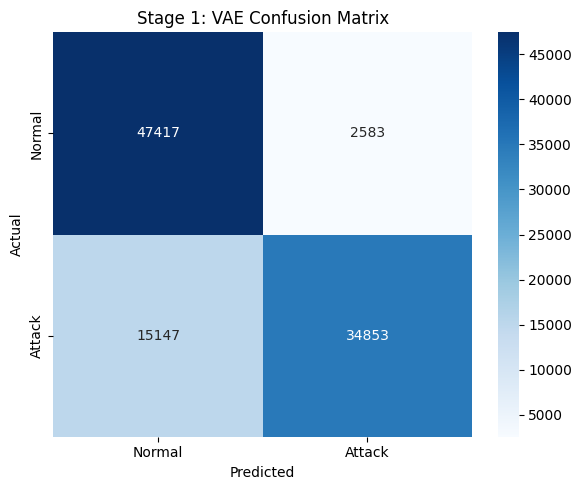

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = y_test
y_pred = vae_results["vae_prediction"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stage 1: VAE Confusion Matrix")
plt.tight_layout()
plt.show()

Stage 2 shape: (50, 13)
Columns:
['flow_number', 'vae_anomaly_score', 'vae_prediction', 'candidate_threats', 'candidate_evidence_strength', 'ai_raw_response', 'threat_type', 'risk_level', 'confidence', 'evidence', 'objective_evidence', 'explanation', 'recommendation']


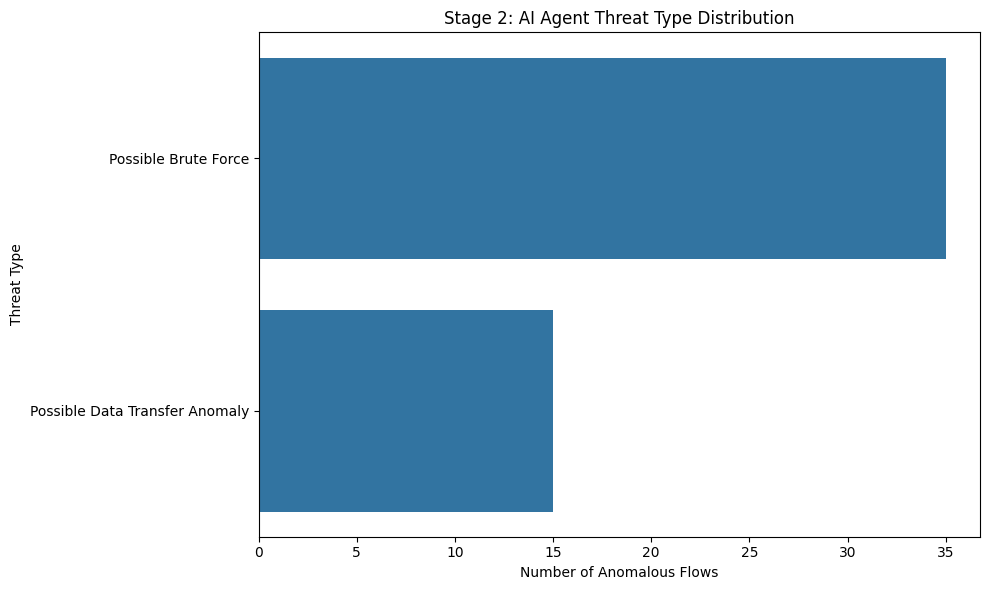

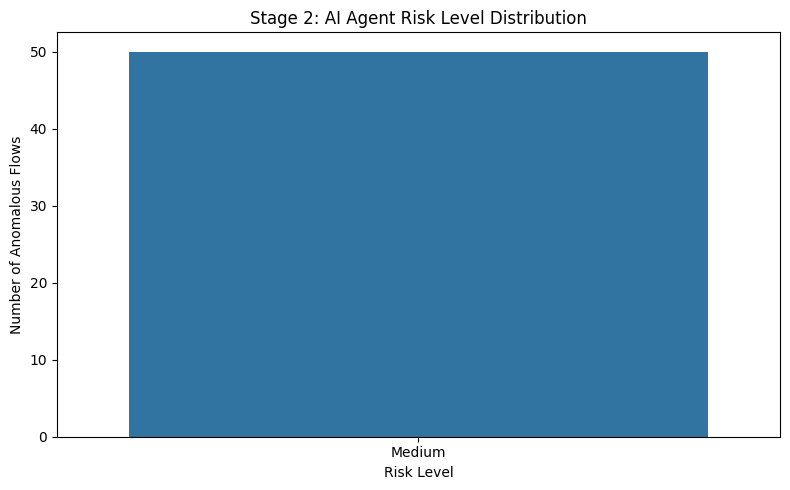

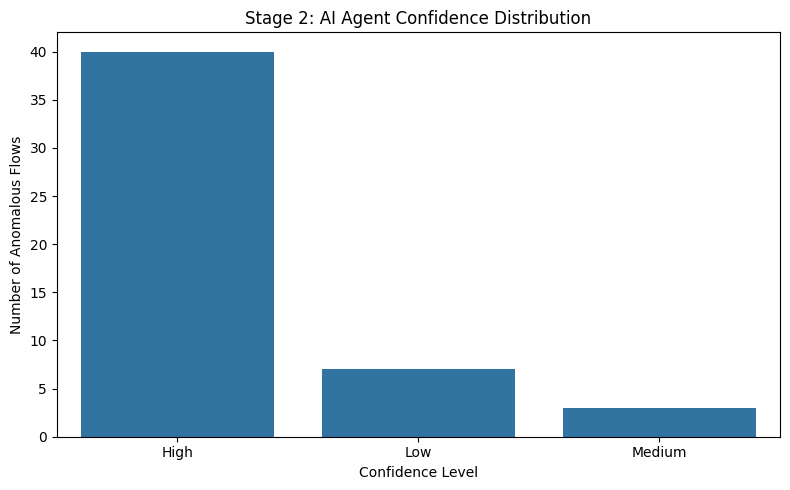

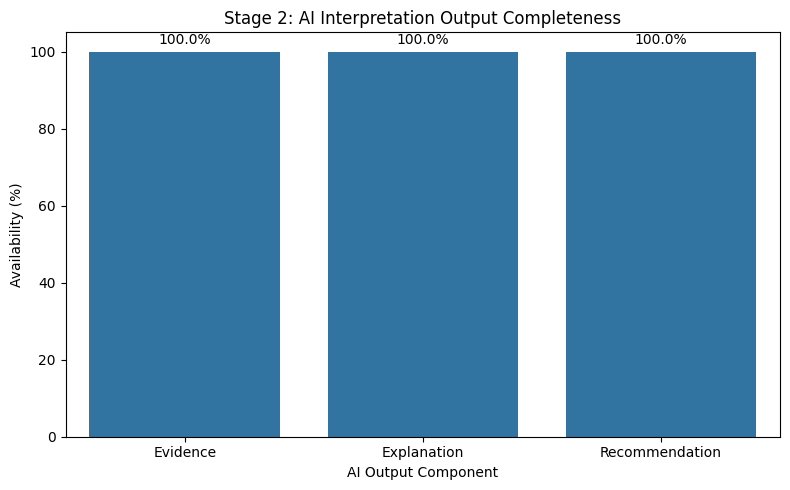

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Stage 2 results
stage2_results = pd.read_csv("/content/vae_ai_results.csv")

print("Stage 2 shape:", stage2_results.shape)
print("Columns:")
print(stage2_results.columns.tolist())

# -----------------------------------------
# 1. Threat Type Distribution
# -----------------------------------------
plt.figure(figsize=(10, 6))

threat_counts = stage2_results["threat_type"].value_counts()

sns.barplot(
    x=threat_counts.values,
    y=threat_counts.index
)

plt.xlabel("Number of Anomalous Flows")
plt.ylabel("Threat Type")
plt.title("Stage 2: AI Agent Threat Type Distribution")
plt.tight_layout()
plt.show()


# -----------------------------------------
# 2. Risk Level Distribution
# -----------------------------------------
plt.figure(figsize=(8, 5))

risk_counts = stage2_results["risk_level"].value_counts()

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Anomalous Flows")
plt.title("Stage 2: AI Agent Risk Level Distribution")
plt.tight_layout()
plt.show()


# -----------------------------------------
# 3. Confidence Distribution
# -----------------------------------------
plt.figure(figsize=(8, 5))

confidence_counts = stage2_results["confidence"].value_counts()

sns.barplot(
    x=confidence_counts.index,
    y=confidence_counts.values
)

plt.xlabel("Confidence Level")
plt.ylabel("Number of Anomalous Flows")
plt.title("Stage 2: AI Agent Confidence Distribution")
plt.tight_layout()
plt.show()


# -----------------------------------------
# 4. Output Completeness
# -----------------------------------------
def available_percentage(column):
    values = (
        stage2_results[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )
    return (values != "").mean() * 100


completeness = pd.Series({
    "Evidence": available_percentage("evidence"),
    "Explanation": available_percentage("explanation"),
    "Recommendation": available_percentage("recommendation")
})

plt.figure(figsize=(8, 5))

sns.barplot(
    x=completeness.index,
    y=completeness.values
)

plt.ylim(0, 105)
plt.ylabel("Availability (%)")
plt.xlabel("AI Output Component")
plt.title("Stage 2: AI Interpretation Output Completeness")

for i, value in enumerate(completeness.values):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# Display 10 example Stage 2 interpretations

display(
    stage2_results[
        [
            "flow_number",
            "vae_anomaly_score",
            "threat_type",
            "risk_level",
            "confidence",
            "evidence",
            "explanation",
            "recommendation"
        ]
    ].head(10)
)

,flow_number,vae_anomaly_score,threat_type,risk_level,confidence,evidence,explanation,recommendation
0,1,4.203490,Possible Brute Force,Medium,High,"The VAE anomaly score indicates elevated activity levels for both active_mean and packet_length_variance features, suggesting abnormal behavior consistent with brute force attacks.","The high VAE anomaly scores for both active_mean and packet_length_variance indicate significant deviations from normal patterns, which aligns with the characteristics typically associated with brute force attacks where large numbers of connections are attempted at once to overwhelm a system's d...",Implement additional authentication measures such as CAPTCHAs or multi-factor authentication to further mitigate the risk of brute force attacks.
1,2,4.904356,Possible Brute Force,Medium,Low,"The VAE anomaly score indicates elevated activity levels for both active_mean and packet_length_variance features, suggesting possible brute force attempts.","The high variance in packet lengths and increased overall activity align with typical characteristics of brute force attacks, where attackers might send large volumes of packets to overwhelm systems. However, this is based on the provided evidence which lacks specific details about the nature of...",Monitor the system closely for any unusual patterns and consider implementing additional security measures such as rate limiting or intrusion detection systems.
2,3,2.004659,Possible Brute Force,Medium,High,"The VAE anomaly score indicates elevated activity levels for both active_mean and packet_length_variance features, suggesting abnormal behavior consistent with brute force attacks.","The high VAE anomaly scores for both active_mean and packet_length_variance indicate significant deviations from normal patterns, which aligns with the characteristics typically associated with brute force attacks where large numbers of packets are sent to overwhelm systems quickly.",Implement additional monitoring and logging mechanisms to track brute force attempts more closely and consider implementing rate limiting on affected services to mitigate potential threats.
3,4,4.883781,Possible Brute Force,Medium,High,"The VAE anomaly score indicates elevated activity levels for active connections and FIN flag count, suggesting potential brute force attempts.","The high VAE anomaly score coupled with elevated observations for active connections and FIN flag count points to possible brute force activity, which requires further investigation for confirmation.",Monitor the system closely for any additional signs of brute force attacks and consider implementing stronger authentication measures.
4,5,1.585737,Possible Brute Force,Medium,High,"The VAE anomaly score indicates elevated activity levels for both idle and active periods, suggesting abnormal behavior consistent with brute force attacks.","The high VAE anomaly score coupled with elevated idle and active period observations aligns closely with known brute force attack patterns, making this candidate plausible.",Implement additional monitoring and logging to track brute force attempts more precisely and consider implementing rate limiting on affected services.
5,6,1.432614,Possible Data Transfer Anomaly,Medium,High,"The VAE anomaly score indicates elevated variance in packet lengths, standard deviations for both forward and backward packet sizes, and maximum packet lengths. These features suggest irregular data transfer patterns that could indicate malicious activity.","The high VAE anomaly score coupled with significant variations in packet length, standard deviation, and maximum packet size suggests abnormal behavior indicative of potential data exfiltration or other unauthorized data transfers. This pattern aligns well with the ""Possible Data Transfer Anomal...","Investigate the source and destination of the transfer, review transferred volume and timing, and check for possible unauthorized data exfiltration."
6,7,0.585518,Possible 

In [ ]:
print("=" * 60)
print("STAGE 1 + STAGE 2 SUMMARY")
print("=" * 60)

print("\nSTAGE 1 — VAE ANOMALY DETECTION")
print("--------------------------------")
print("Accuracy : 82%")
print("Precision: 84%")
print("Recall   : 82%")
print("F1-score : 82%")
print("Threshold:", 0.5515933)

print("\nSTAGE 2 — AI THREAT INTERPRETATION")
print("-----------------------------------")

print("\nThreat Types:")
print(stage2_results["threat_type"].value_counts())

print("\nRisk Levels:")
print(stage2_results["risk_level"].value_counts())

print("\nConfidence:")
print(stage2_results["confidence"].value_counts())

print("\nOutput Completeness:")
print(completeness)

STAGE 1 + STAGE 2 SUMMARY

STAGE 1 — VAE ANOMALY DETECTION
--------------------------------
Accuracy : 82%
Precision: 84%
Recall   : 82%
F1-score : 82%
Threshold: 0.5515933

STAGE 2 — AI THREAT INTERPRETATION
-----------------------------------

Threat Types:
threat_type
Possible Brute Force              35
Possible Data Transfer Anomaly    15
Name: count, dtype: int64

Risk Levels:
risk_level
Medium    50
Name: count, dtype: int64

Confidence:
confidence
High      40
Low        7
Medium     3
Name: count, dtype: int64

Output Completeness:
Evidence          100.0
Explanation       100.0
Recommendation    100.0
dtype: float64


stage3


In [ ]:
# ================================================================
# STAGE 3 — PART 1
# LOAD VAE RESULTS + STAGE 2 RESULTS
# ================================================================

import os
import pandas as pd
import numpy as np

print("=" * 70)
print("STAGE 3 — PART 1: LOADING DATA")
print("=" * 70)

# ------------------------------------------------
# File paths
# ------------------------------------------------

VAE_FILE = "/content/vae_results.csv"
STAGE2_FILE = "/content/vae_ai_results.csv"


# ------------------------------------------------
# Check files
# ------------------------------------------------

print("\nChecking required files...")

print(
    "VAE results exists:",
    os.path.exists(VAE_FILE)
)

print(
    "Stage 2 results exists:",
    os.path.exists(STAGE2_FILE)
)


if not os.path.exists(VAE_FILE):

    raise FileNotFoundError(
        "vae_results.csv was not found in /content/"
    )


if not os.path.exists(STAGE2_FILE):

    raise FileNotFoundError(
        "vae_ai_results.csv was not found in /content/"
    )


# ------------------------------------------------
# Load files
# ------------------------------------------------

vae_results = pd.read_csv(
    VAE_FILE
)

stage2_results = pd.read_csv(
    STAGE2_FILE
)


print("\nVAE results loaded.")
print(
    "VAE shape:",
    vae_results.shape
)


print("\nStage 2 results loaded.")
print(
    "Stage 2 shape:",
    stage2_results.shape
)


# ------------------------------------------------
# Display columns
# ------------------------------------------------

print("\n" + "=" * 70)
print("VAE COLUMNS")
print("=" * 70)

print(
    vae_results.columns.tolist()
)


print("\n" + "=" * 70)
print("STAGE 2 COLUMNS")
print("=" * 70)

print(
    stage2_results.columns.tolist()
)


# ------------------------------------------------
# Find VAE score column
# ------------------------------------------------

possible_score_columns = [
    "vae_anomaly_score",
    "anomaly_score",
    "reconstruction_error",
    "reconstruction_loss"
]

score_col = None

for col in possible_score_columns:

    if col in vae_results.columns:

        score_col = col
        break


# ------------------------------------------------
# Find VAE prediction column
# ------------------------------------------------

possible_prediction_columns = [
    "vae_prediction",
    "prediction",
    "anomaly_prediction"
]

prediction_col = None

for col in possible_prediction_columns:

    if col in vae_results.columns:

        prediction_col = col
        break


print("\nDetected VAE score column:")
print(score_col)

print("\nDetected VAE prediction column:")
print(prediction_col)


if score_col is None:

    raise ValueError(
        "Could not find VAE anomaly score column."
    )


if prediction_col is None:

    raise ValueError(
        "Could not find VAE prediction column."
    )


# ------------------------------------------------
# Count normal / anomalous flows
# ------------------------------------------------

normal_count = (
    vae_results[prediction_col] == 0
).sum()

anomaly_count = (
    vae_results[prediction_col] == 1
).sum()


print("\n" + "=" * 70)
print("VAE FLOW COUNTS")
print("=" * 70)

print(
    "Normal flows:",
    normal_count
)

print(
    "Anomalous flows:",
    anomaly_count
)


# ------------------------------------------------
# Select anomalous flows
# ------------------------------------------------

vae_anomalies = vae_results[
    vae_results[prediction_col] == 1
].copy()


# Same 50 anomalous flows used by Stage 2

stage3_input = (
    vae_anomalies
    .head(50)
    .copy()
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("STAGE 3 INPUT")
print("=" * 70)

print(
    "Stage 3 input shape:",
    stage3_input.shape
)

print(
    "Number of anomalous flows:",
    len(stage3_input)
)


# ------------------------------------------------
# Check that network features are present
# ------------------------------------------------

print("\nFirst 20 Stage 3 columns:")

print(
    stage3_input.columns.tolist()[:20]
)


print("\nStage 3 input preview:")

display(
    stage3_input.head()
)


print("\n" + "=" * 70)
print("PART 1 COMPLETE")
print("=" * 70)

print(
    "Original VAE network features are now available "
    "for Stage 3."
)

STAGE 3 — PART 1: LOADING DATA

Checking required files...
VAE results exists: True
Stage 2 results exists: True

VAE results loaded.
VAE shape: (100000, 72)

Stage 2 results loaded.
Stage 2 shape: (50, 13)

VAE COLUMNS
['Protocol', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Fwd_Packets_Length_Total', 'Bwd_Packets_Length_Total', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_URG_Flags', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s', 'Packet_Length_Min', 'Packet_Length_Max', 'Packet_Length_Mean', 'Packet_Length_S

,Protocol,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Fwd_Packets_Length_Total,Bwd_Packets_Length_Total,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,actual_label,anomaly_score,vae_prediction
0,6,98325123,6,6,11595,345,7251,0,1932.500000,3131.772700,...,0.000000,12896,12896,98300000.0,0.0,98300000,98300000,0,1.169826,1
1,6,20,1,4,6,24,6,6,6.000000,0.000000,...,0.000000,0,0,0.0,0.0,0,0,0,0.668652,1
2,6,27,1,2,6,37,6,6,6.000000,0.000000,...,0.000000,0,0,0.0,0.0,0,0,0,0.672417,1
3,6,1,2,0,31,0,31,0,15.500000,21.920311,...,0.000000,0,0,0.0,0.0,0,0,0,0.554347,1
4,6,63815985,7,2,187,92,46,6,26.714285,20.089087,...,37.476658,249253,249200,31652676.0,37482360.0,58156707,5148647,0,2.206593,1



PART 1 COMPLETE
Original VAE network features are now available for Stage 3.


In [ ]:
# ================================================================
# STAGE 3 — PART 2
# FINAL ROBUST OBJECTIVE FEATURE ANALYSIS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("STAGE 3 — PART 2: FINAL ROBUST FEATURE ANALYSIS")
print("=" * 70)


# ------------------------------------------------
# 1. FEATURE SELECTION
# ------------------------------------------------

EXCLUDE_COLS = {
    "actual_label",
    "label",
    "attack",
    "attack_label",
    "target",
    "class",

    "anomaly_score",
    "vae_prediction",
    "vae_anomaly_score",

    "flow_number",
    "timestamp",
    "flow id",
    "flow_id",
    "source ip",
    "destination ip",
    "src_ip",
    "dst_ip"
}


feature_cols = []

for col in stage3_input.columns:

    col_lower = str(col).lower().strip()

    if col_lower in EXCLUDE_COLS:
        continue

    if pd.api.types.is_numeric_dtype(
        stage3_input[col]
    ):
        feature_cols.append(col)


# Protocol is categorical, not a continuous
# behavioral measurement.
if "Protocol" in feature_cols:
    feature_cols.remove("Protocol")


print("\nUsable network features:", len(feature_cols))


# ------------------------------------------------
# 2. CLEAN FEATURE GROUPS
# ------------------------------------------------

FEATURE_GROUPS = {

    "volume_rate": [
        "Total_Fwd_Packets",
        "Total_Backward_Packets",
        "Fwd_Packets_Length_Total",
        "Bwd_Packets_Length_Total",
        "Flow_Bytes/s",
        "Flow_Packets/s",
        "Fwd_Packets/s",
        "Bwd_Packets/s",
        "Subflow_Fwd_Packets",
        "Subflow_Fwd_Bytes",
        "Subflow_Bwd_Packets",
        "Subflow_Bwd_Bytes",
        "Fwd_Act_Data_Packets"
    ],

    "duration": [
        "Flow_Duration"
    ],

    "iat": [
        "Flow_IAT_Mean",
        "Flow_IAT_Std",
        "Flow_IAT_Max",
        "Flow_IAT_Min",

        "Fwd_IAT_Total",
        "Fwd_IAT_Mean",
        "Fwd_IAT_Std",
        "Fwd_IAT_Max",
        "Fwd_IAT_Min",

        "Bwd_IAT_Total",
        "Bwd_IAT_Mean",
        "Bwd_IAT_Std",
        "Bwd_IAT_Max",
        "Bwd_IAT_Min"
    ],

    "packet_length": [
        "Fwd_Packet_Length_Max",
        "Fwd_Packet_Length_Min",
        "Fwd_Packet_Length_Mean",
        "Fwd_Packet_Length_Std",

        "Bwd_Packet_Length_Max",
        "Bwd_Packet_Length_Min",
        "Bwd_Packet_Length_Mean",
        "Bwd_Packet_Length_Std",

        "Packet_Length_Min",
        "Packet_Length_Max",
        "Packet_Length_Mean",
        "Packet_Length_Std",
        "Packet_Length_Variance",

        "Avg_Packet_Size",
        "Avg_Fwd_Segment_Size",
        "Avg_Bwd_Segment_Size",
        "Fwd_Seg_Size_Min"
    ],

    "tcp_flags": [
        "FIN_Flag_Count",
        "SYN_Flag_Count",
        "RST_Flag_Count",
        "PSH_Flag_Count",
        "ACK_Flag_Count",
        "URG_Flag_Count",
        "CWE_Flag_Count",
        "ECE_Flag_Count",
        "Fwd_PSH_Flags",
        "Fwd_URG_Flags"
    ],

    "direction": [
        "Down/Up_Ratio",
        "Fwd_Header_Length",
        "Bwd_Header_Length",
        "Init_Fwd_Win_Bytes",
        "Init_Bwd_Win_Bytes"
    ],

    "active_idle": [
        "Active_Mean",
        "Active_Std",
        "Active_Max",
        "Active_Min",
        "Idle_Mean",
        "Idle_Std",
        "Idle_Max",
        "Idle_Min"
    ]
}


for group in FEATURE_GROUPS:

    FEATURE_GROUPS[group] = [
        col
        for col in FEATURE_GROUPS[group]
        if col in feature_cols
    ]


print("\n" + "=" * 70)
print("FEATURE GROUPS")
print("=" * 70)

for group, features in FEATURE_GROUPS.items():

    print(
        f"{group:15s}: {len(features)}"
    )


print(
    "\nPort features: 0"
)

print(
    "Port Scan assessment: DISABLED"
)


# ------------------------------------------------
# 3. NORMAL BASELINE
# ------------------------------------------------

normal_data = vae_results[
    vae_results[prediction_col] == 0
].copy()


print("\nNormal baseline flows:", len(normal_data))


if len(normal_data) < 100:

    raise ValueError(
        "Insufficient normal flows."
    )


# ------------------------------------------------
# 4. NUMERIC CLEANING
# ------------------------------------------------

normal_matrix = normal_data[
    feature_cols
].copy()


stage3_matrix = stage3_input[
    feature_cols
].copy()


normal_matrix = normal_matrix.replace(
    [np.inf, -np.inf],
    np.nan
)

stage3_matrix = stage3_matrix.replace(
    [np.inf, -np.inf],
    np.nan
)


# ------------------------------------------------
# 5. ROBUST BASELINE
# ------------------------------------------------

normal_median = normal_matrix.median(
    numeric_only=True
)

Q1 = normal_matrix.quantile(
    0.25,
    numeric_only=True
)

Q3 = normal_matrix.quantile(
    0.75,
    numeric_only=True
)

normal_IQR = Q3 - Q1


# ------------------------------------------------
# 6. IMPORTANT FIX:
#    ZERO/VERY SMALL IQR
# ------------------------------------------------
#
# If a feature has almost no variation in normal
# traffic, using:
#
#       |x - median| / IQR
#
# creates enormous artificial deviations.
#
# We therefore use a robust scale based on both
# IQR and MAD.
# ------------------------------------------------

normal_MAD = (
    normal_matrix
    .sub(normal_median, axis="columns")
    .abs()
    .median()
)


# Convert MAD to approximately standard-deviation
# scale for robust statistics.
mad_scale = (
    normal_MAD * 1.4826
)


robust_scale = normal_IQR / 1.349


# Select the larger stable scale.
robust_scale = pd.concat(
    [
        robust_scale,
        mad_scale
    ],
    axis=1
).max(axis=1)


# ------------------------------------------------
# 7. FINAL FALLBACK SCALE
# ------------------------------------------------

normal_std = normal_matrix.std(
    numeric_only=True
)


for col in robust_scale.index:

    scale = robust_scale[col]

    if (
        pd.isna(scale)
        or scale < 1e-6
    ):

        std_value = normal_std.get(
            col,
            np.nan
        )

        if (
            not pd.isna(std_value)
            and std_value > 1e-6
        ):

            robust_scale[col] = std_value

        else:

            # Absolute fallback.
            #
            # We intentionally do NOT use a tiny
            # epsilon because that would create
            # artificial deviations of billions.
            #
            # A scale of 1 means the feature must
            # differ materially from the baseline
            # before becoming significant.
            robust_scale[col] = 1.0


print("\nRobust baseline constructed.")


# ------------------------------------------------
# 8. ROBUST FEATURE DEVIATION
# ------------------------------------------------

def calculate_feature_deviations(row):

    deviations = {}

    for col in feature_cols:

        value = row.get(
            col,
            np.nan
        )

        median = normal_median.get(
            col,
            np.nan
        )

        scale = robust_scale.get(
            col,
            np.nan
        )


        if pd.isna(value):
            continue

        if pd.isna(median):
            continue

        if pd.isna(scale):
            continue


        raw_deviation = abs(
            float(value)
            - float(median)
        ) / (
            float(scale)
            + 1e-9
        )


        # ------------------------------------------------
        # CAP EXTREME DEVIATIONS
        # ------------------------------------------------
        #
        # This prevents one pathological feature from
        # producing scores such as 10^16 and completely
        # dominating the threat classifier.
        #
        deviation = min(
            raw_deviation,
            20.0
        )


        deviations[col] = float(
            deviation
        )


    return deviations


# ------------------------------------------------
# 9. GROUP SCORE
# ------------------------------------------------

def calculate_group_score(
    deviations,
    features
):

    values = [
        deviations[col]
        for col in features
        if col in deviations
    ]


    if len(values) == 0:

        return 0.0


    values = np.asarray(
        values,
        dtype=float
    )


    values = values[
        np.isfinite(values)
    ]


    if len(values) == 0:

        return 0.0


    # Median + upper percentile gives a stable
    # representation of group-level abnormality.
    median_score = np.median(
        values
    )

    upper_score = np.percentile(
        values,
        75
    )


    score = (
        0.4 * median_score
        +
        0.6 * upper_score
    )


    return float(
        min(score, 20.0)
    )


# ------------------------------------------------
# 10. TOP FEATURES
# ------------------------------------------------

def get_top_features(
    row,
    deviations,
    top_n=8
):

    result = []


    for feature, deviation in (
        deviations.items()
    ):

        value = row.get(
            feature,
            np.nan
        )


        if pd.isna(value):
            continue


        result.append(
            (
                feature,
                float(value),
                float(deviation)
            )
        )


    result.sort(
        key=lambda x: x[2],
        reverse=True
    )


    return result[:top_n]


# ------------------------------------------------
# 11. ANALYZE ALL STAGE 3 FLOWS
# ------------------------------------------------

objective_analysis_rows = []


for idx, row in stage3_input.iterrows():

    deviations = (
        calculate_feature_deviations(
            row
        )
    )


    group_scores = {}


    for group, features in (
        FEATURE_GROUPS.items()
    ):

        group_scores[group] = (
            calculate_group_score(
                deviations,
                features
            )
        )


    top_features = (
        get_top_features(
            row,
            deviations,
            top_n=8
        )
    )


    objective_analysis_rows.append({

        "row_index": idx,

        "vae_anomaly_score":
            float(row[score_col]),

        "group_scores":
            group_scores,

        "top_features":
            top_features,

        "feature_deviations":
            deviations
    })


objective_analysis = pd.DataFrame(
    objective_analysis_rows
)


# ------------------------------------------------
# 12. DISPLAY RESULTS
# ------------------------------------------------

print("\n" + "=" * 70)
print("CORRECTED ANALYSIS — FIRST 5 FLOWS")
print("=" * 70)


for i in range(
    min(5, len(objective_analysis))
):

    result = objective_analysis.iloc[i]


    print(
        f"\nFlow {i + 1}"
    )


    print(
        "VAE anomaly score:",
        round(
            result[
                "vae_anomaly_score"
            ],
            4
        )
    )


    print(
        "\nGroup scores:"
    )


    ranked_groups = sorted(
        result[
            "group_scores"
        ].items(),
        key=lambda x: x[1],
        reverse=True
    )


    for group, score in ranked_groups:

        print(
            f"  {group:15s}: "
            f"{score:.3f}"
        )


    print(
        "\nTop feature deviations:"
    )


    for (
        feature,
        value,
        deviation
    ) in result[
        "top_features"
    ]:

        print(
            f"  {feature:30s} "
            f"value={value:.4f} "
            f"deviation={deviation:.3f}"
        )


# ------------------------------------------------
# 13. SAVE
# ------------------------------------------------

objective_analysis.to_pickle(
    "/content/stage3_objective_analysis.pkl"
)


print("\nSaved:")
print(
    "/content/stage3_objective_analysis.pkl"
)


print("\n" + "=" * 70)
print("PART 2 COMPLETE")
print("=" * 70)

STAGE 3 — PART 2: FINAL ROBUST FEATURE ANALYSIS

Usable network features: 68

FEATURE GROUPS
volume_rate    : 13
duration       : 1
iat            : 14
packet_length  : 17
tcp_flags      : 10
direction      : 5
active_idle    : 8

Port features: 0
Port Scan assessment: DISABLED

Normal baseline flows: 62564

Robust baseline constructed.

CORRECTED ANALYSIS — FIRST 5 FLOWS

Flow 1
VAE anomaly score: 1.1698

Group scores:
  duration       : 20.000
  iat            : 20.000
  packet_length  : 16.674
  active_idle    : 5.479
  direction      : 2.002
  volume_rate    : 1.391
  tcp_flags      : 0.000

Top feature deviations:
  Flow_Duration                  value=98325123.0000 deviation=20.000
  Fwd_Packets_Length_Total       value=11595.0000 deviation=20.000
  Fwd_Packet_Length_Max          value=7251.0000 deviation=20.000
  Fwd_Packet_Length_Mean         value=1932.5000 deviation=20.000
  Fwd_Packet_Length_Std          value=3131.7727 deviation=20.000
  Flow_IAT_Mean                  value

In [ ]:
# ================================================================
# STAGE 3 — PART 3
# FINAL CONSERVATIVE THREAT CANDIDATE GENERATION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("STAGE 3 — PART 3: FINAL THREAT CANDIDATES")
print("=" * 70)


# ------------------------------------------------
# 1. CHECK PART 2
# ------------------------------------------------

if "objective_analysis" not in globals():

    raise RuntimeError(
        "Run corrected Part 2 first."
    )


# ------------------------------------------------
# 2. CANDIDATE GENERATION
# ------------------------------------------------
#
# IMPORTANT:
#
# These are NOT ground-truth attack labels.
#
# They are behavioral hypotheses generated from:
#
# VAE anomaly score
# +
# robust feature deviations
# +
# behavioral groups
#
# RAG will later provide cybersecurity knowledge
# for interpreting these hypotheses.
# ------------------------------------------------


def generate_candidates(
    group_scores,
    vae_score
):

    volume = group_scores.get(
        "volume_rate",
        0.0
    )

    duration = group_scores.get(
        "duration",
        0.0
    )

    iat = group_scores.get(
        "iat",
        0.0
    )

    packet = group_scores.get(
        "packet_length",
        0.0
    )

    flags = group_scores.get(
        "tcp_flags",
        0.0
    )

    direction = group_scores.get(
        "direction",
        0.0
    )

    active_idle = group_scores.get(
        "active_idle",
        0.0
    )


    candidates = []


    # ------------------------------------------------
    # 1. HIGH-VOLUME TRAFFIC
    # ------------------------------------------------
    #
    # DDoS is NOT assigned here.
    #
    # Reason:
    # We do not have source-IP distribution in the
    # current feature table.
    #
    # Therefore:
    #
    # high volume -> Possible DoS
    #
    # rather than:
    #
    # high volume -> Possible DDoS
    #
    if volume >= 8:

        candidates.append(
            (
                "Possible DoS",
                volume
            )
        )


    # ------------------------------------------------
    # 2. BRUTE FORCE
    # ------------------------------------------------
    #
    # Requires simultaneous timing,
    # directional and duration abnormalities.
    #
    if (
        iat >= 6
        and direction >= 2.5
        and duration >= 2.5
    ):

        score = (
            iat
            + direction
            + duration
        ) / 3.0


        candidates.append(
            (
                "Possible Brute Force",
                score
            )
        )


    # ------------------------------------------------
    # 3. BOTNET
    # ------------------------------------------------
    #
    # Requires BOTH:
    #
    # active/idle abnormality
    # +
    # packet behavior abnormality
    #
    if (
        active_idle >= 6
        and packet >= 4
    ):

        score = (
            active_idle
            + packet
        ) / 2.0


        candidates.append(
            (
                "Possible Botnet Activity",
                score
            )
        )


    # ------------------------------------------------
    # 4. EXPLOITATION
    # ------------------------------------------------
    #
    # Requires:
    #
    # TCP flag behavior
    # +
    # timing abnormality
    # +
    # directional behavior
    #
    if (
        flags >= 6
        and iat >= 4
        and direction >= 2
    ):

        score = (
            flags
            + iat
            + direction
        ) / 3.0


        candidates.append(
            (
                "Possible Exploitation",
                score
            )
        )


    # ------------------------------------------------
    # 5. DATA TRANSFER ANOMALY
    # ------------------------------------------------

    if (
        volume >= 5
        or packet >= 6
    ):

        score = max(
            volume,
            packet
        )


        candidates.append(
            (
                "Possible Data Transfer Anomaly",
                score
            )
        )


    # ------------------------------------------------
    # 6. OTHER SUSPICIOUS ACTIVITY
    # ------------------------------------------------

    if not candidates:

        candidates.append(
            (
                "Other Suspicious Activity",
                max(
                    group_scores.values()
                )
                if group_scores
                else 0.0
            )
        )


    # ------------------------------------------------
    # 7. REMOVE DUPLICATE THREATS
    # ------------------------------------------------

    unique = {}

    for threat, score in candidates:

        if (
            threat not in unique
            or score > unique[threat]
        ):

            unique[threat] = score


    candidates = [
        (
            threat,
            score
        )
        for threat, score
        in unique.items()
    ]


    # ------------------------------------------------
    # 8. SORT
    # ------------------------------------------------

    candidates.sort(
        key=lambda x: x[1],
        reverse=True
    )


    return candidates


# ------------------------------------------------
# 3. OBJECTIVE EVIDENCE
# ------------------------------------------------

def build_evidence(
    row,
    analysis
):

    vae_score = float(
        row[score_col]
    )


    group_scores = analysis[
        "group_scores"
    ]


    top_features = analysis[
        "top_features"
    ]


    evidence = []


    # VAE evidence
    evidence.append(
        f"VAE anomaly score={vae_score:.4f}"
    )


    # Only include meaningful deviations
    strong_features = [
        item
        for item in top_features
        if item[2] >= 2.0
    ]


    for (
        feature,
        value,
        deviation
    ) in strong_features[:5]:

        evidence.append(
            f"{feature}={value:.4f} "
            f"(robust deviation={deviation:.2f})"
        )


    # Strong behavioral groups
    ranked_groups = sorted(
        group_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )


    strong_groups = [
        (
            group,
            score
        )
        for group, score
        in ranked_groups
        if score >= 2.0
    ]


    if strong_groups:

        group_text = [
            f"{group}={score:.2f}"
            for group, score
            in strong_groups[:3]
        ]


        evidence.append(
            "behavioral groups: "
            + ", ".join(group_text)
        )


    return (
        "Observed flow evidence: "
        + "; ".join(evidence)
        + "."
    )


# ------------------------------------------------
# 4. CONFIDENCE
# ------------------------------------------------

def determine_confidence(
    candidate_score,
    vae_score
):

    if (
        candidate_score >= 8
        and vae_score >= 1.0
    ):

        return "High"


    if (
        candidate_score >= 4
        or vae_score >= 1.0
    ):

        return "Medium"


    return "Low"


# ------------------------------------------------
# 5. RISK
# ------------------------------------------------

def determine_risk(
    threat,
    candidate_score,
    vae_score
):

    threat = str(
        threat
    ).lower()


    if (
        "dos" in threat
        and candidate_score >= 8
    ):

        return "High"


    if (
        candidate_score >= 8
        and vae_score >= 1.0
    ):

        return "High"


    if (
        candidate_score >= 4
        or vae_score >= 1.0
    ):

        return "Medium"


    return "Low"


# ------------------------------------------------
# 6. BUILD FINAL CANDIDATE TABLE
# ------------------------------------------------

candidate_rows = []


for idx, row in stage3_input.iterrows():

    analysis = objective_analysis.iloc[idx]


    group_scores = analysis[
        "group_scores"
    ]


    vae_score = float(
        row[score_col]
    )


    candidates = generate_candidates(
        group_scores,
        vae_score
    )


    selected_threat = candidates[0][0]

    selected_score = float(
        candidates[0][1]
    )


    confidence = (
        determine_confidence(
            selected_score,
            vae_score
        )
    )


    risk = determine_risk(
        selected_threat,
        selected_score,
        vae_score
    )


    evidence = build_evidence(
        row,
        analysis
    )


    candidate_rows.append({

        "row_index":
            idx,

        "vae_anomaly_score":
            vae_score,

        "candidate_threats":
            " | ".join(
                x[0]
                for x in candidates
            ),

        "candidate_scores":
            " | ".join(
                f"{x[1]:.3f}"
                for x in candidates
            ),

        "selected_candidate":
            selected_threat,

        "candidate_score":
            selected_score,

        "risk_level":
            risk,

        "confidence":
            confidence,

        "objective_evidence":
            evidence
    })


objective_candidates = pd.DataFrame(
    candidate_rows
)


# ------------------------------------------------
# 7. DISPLAY FIRST 10
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL OBJECTIVE CANDIDATES — FIRST 10")
print("=" * 70)


for i in range(
    min(10, len(objective_candidates))
):

    result = (
        objective_candidates.iloc[i]
    )


    print(
        f"\nFlow {i + 1}"
    )


    print(
        "VAE anomaly score:",
        round(
            result[
                "vae_anomaly_score"
            ],
            4
        )
    )


    print(
        "Candidate threats:",
        result[
            "candidate_threats"
        ]
    )


    print(
        "Candidate scores:",
        result[
            "candidate_scores"
        ]
    )


    print(
        "Selected:",
        result[
            "selected_candidate"
        ]
    )


    print(
        "Risk:",
        result[
            "risk_level"
        ]
    )


    print(
        "Confidence:",
        result[
            "confidence"
        ]
    )


    print(
        "Evidence:"
    )


    print(
        result[
            "objective_evidence"
        ]
    )


# ------------------------------------------------
# 8. DISTRIBUTIONS
# ------------------------------------------------

print("\n" + "=" * 70)
print("THREAT DISTRIBUTION")
print("=" * 70)

print(
    objective_candidates[
        "selected_candidate"
    ].value_counts()
)


print("\n" + "=" * 70)
print("RISK DISTRIBUTION")
print("=" * 70)

print(
    objective_candidates[
        "risk_level"
    ].value_counts()
)


print("\n" + "=" * 70)
print("CONFIDENCE DISTRIBUTION")
print("=" * 70)

print(
    objective_candidates[
        "confidence"
    ].value_counts()
)


# ------------------------------------------------
# 9. SAVE
# ------------------------------------------------

objective_candidates.to_csv(
    "/content/stage3_objective_candidates.csv",
    index=False
)


print("\nSaved:")
print(
    "/content/stage3_objective_candidates.csv"
)


print("\n" + "=" * 70)
print("PART 3 COMPLETE")
print("=" * 70)

print(
    "Objective candidate generation complete."
)

print(
    "DDoS is intentionally not assigned from a single flow."
)

print(
    "Port Scan is unavailable because port features are absent."
)

print(
    "These are behavioral candidates, not ground-truth labels."
)

STAGE 3 — PART 3: FINAL THREAT CANDIDATES

FINAL OBJECTIVE CANDIDATES — FIRST 10

Flow 1
VAE anomaly score: 1.1698
Candidate threats: Possible Data Transfer Anomaly
Candidate scores: 16.674
Selected: Possible Data Transfer Anomaly
Risk: High
Confidence: High
Evidence:
Observed flow evidence: VAE anomaly score=1.1698; Flow_Duration=98325123.0000 (robust deviation=20.00); Fwd_Packets_Length_Total=11595.0000 (robust deviation=20.00); Fwd_Packet_Length_Max=7251.0000 (robust deviation=20.00); Fwd_Packet_Length_Mean=1932.5000 (robust deviation=20.00); Fwd_Packet_Length_Std=3131.7727 (robust deviation=20.00); behavioral groups: duration=20.00, iat=20.00, packet_length=16.67.

Flow 2
VAE anomaly score: 0.6687
Candidate threats: Possible DoS | Possible Data Transfer Anomaly
Candidate scores: 12.260 | 12.260
Selected: Possible DoS
Risk: High
Confidence: Medium
Evidence:
Observed flow evidence: VAE anomaly score=0.6687; Flow_Bytes/s=1500000.0000 (robust deviation=20.00); Flow_Packets/s=250000.000

In [ ]:
# ================================================================
# STAGE 3 — PART 4
# RAG KNOWLEDGE BASE + RETRIEVER
# ================================================================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("=" * 70)
print("STAGE 3 — PART 4: RAG KNOWLEDGE BASE + RETRIEVER")
print("=" * 70)

# ------------------------------------------------
# 1. CYBERSECURITY KNOWLEDGE BASE
# ------------------------------------------------

knowledge_base = [

    {
        "id": "KB001",
        "topic": "Brute Force",
        "text": """
        Brute force attacks involve repeated attempts to authenticate to a
        service. Network indicators may include repeated connections to the
        same service, repeated request-response behavior, unusual connection
        timing, and repeated traffic patterns. Flow-level evidence alone does
        not prove successful authentication or compromise.
        """
    },

    {
        "id": "KB002",
        "topic": "Port Scan",
        "text": """
        Port scanning involves probing multiple destination ports or services
        to identify reachable network services. Evidence normally includes
        connections to multiple ports or a large number of service probes.
        A single flow without port information is insufficient to establish
        a port scan.
        """
    },

    {
        "id": "KB003",
        "topic": "Denial of Service",
        "text": """
        Denial of Service activity can involve unusually high traffic rates,
        packet rates, byte rates, or connection volume directed toward a
        service or host. A single anomalous flow may be consistent with
        high-volume behavior but does not by itself establish an attack.
        """
    },

    {
        "id": "KB004",
        "topic": "Distributed Denial of Service",
        "text": """
        Distributed Denial of Service involves traffic originating from
        multiple distributed sources toward a target. Source diversity and
        traffic aggregation are important evidence. A single network flow
        cannot independently establish distributed denial of service.
        """
    },

    {
        "id": "KB005",
        "topic": "Botnet Activity",
        "text": """
        Botnet activity may involve periodic or unusual communication
        patterns, persistent active and idle periods, repeated outbound
        communication, and command-and-control-like behavior. Flow-level
        anomalies alone do not prove malware or botnet membership.
        """
    },

    {
        "id": "KB006",
        "topic": "Exploitation",
        "text": """
        Exploitation attempts may involve unusual connection behavior,
        abnormal protocol or packet characteristics, suspicious TCP flags,
        and repeated interactions with a vulnerable service. Flow features
        alone cannot prove that exploitation was successful.
        """
    },

    {
        "id": "KB007",
        "topic": "Data Transfer Anomaly",
        "text": """
        Data transfer anomalies may involve unusually large byte volumes,
        packet volumes, unusual packet lengths, or unexpected transfer rates.
        Such behavior may require investigation for possible unauthorized
        transfer or exfiltration, but unusual volume alone does not prove
        data theft.
        """
    },

    {
        "id": "KB008",
        "topic": "Network Anomaly",
        "text": """
        Network anomalies represent traffic behavior that differs
        substantially from a learned or expected baseline. Possible causes
        include unusual timing, packet characteristics, traffic volume,
        connection behavior, configuration changes, or malicious activity.
        An anomaly is not automatically an attack.
        """
    },

    {
        "id": "KB009",
        "topic": "Incident Investigation",
        "text": """
        Investigation of suspicious network traffic should examine source and
        destination systems, connection timing, traffic volume, packet
        characteristics, related flows, host logs, authentication records,
        and repeated activity. Flow-level evidence should be correlated with
        additional telemetry before confirming an incident.
        """
    },

    {
        "id": "KB010",
        "topic": "Defensive Monitoring",
        "text": """
        Recommended defensive actions include monitoring repeated anomalous
        activity, reviewing related network and host logs, validating source
        and destination systems, applying rate limiting when appropriate,
        reviewing access controls, and investigating repeated or escalating
        behavior.
        """
    }
]

kb_df = pd.DataFrame(knowledge_base)

print("\nKnowledge base documents:", len(kb_df))

print("\nKnowledge base topics:")
for _, row in kb_df.iterrows():
    print(f"{row['id']} — {row['topic']}")

# ------------------------------------------------
# 2. CREATE TF-IDF INDEX
# ------------------------------------------------

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True
)

kb_matrix = vectorizer.fit_transform(
    kb_df["text"].tolist()
)

print("\nTF-IDF matrix shape:", kb_matrix.shape)

# ------------------------------------------------
# 3. RETRIEVAL FUNCTION
# ------------------------------------------------

def retrieve_documents(query, top_k=3):

    query_vector = vectorizer.transform([query])

    similarity = cosine_similarity(
        query_vector,
        kb_matrix
    )[0]

    ranked_indices = np.argsort(
        similarity
    )[::-1][:top_k]

    retrieved = []

    for idx in ranked_indices:

        retrieved.append({
            "id": kb_df.iloc[idx]["id"],
            "topic": kb_df.iloc[idx]["topic"],
            "text": kb_df.iloc[idx]["text"].strip(),
            "similarity": float(similarity[idx])
        })

    return retrieved

# ------------------------------------------------
# 4. FLOW-SPECIFIC RAG QUERY
# ------------------------------------------------

def build_rag_query(row, candidate_row):

    query_parts = []

    query_parts.append(
        "cybersecurity interpretation of anomalous network traffic"
    )

    query_parts.append(
        f"VAE anomaly score {float(row[score_col]):.4f}"
    )

    query_parts.append(
        f"candidate threat {candidate_row['selected_candidate']}"
    )

    # Add strongest behavioral groups
    if "group_scores" in candidate_row:
        group_scores = candidate_row["group_scores"]

        ranked_groups = sorted(
            group_scores.items(),
            key=lambda x: x[1],
            reverse=True
        )

        for group, score in ranked_groups[:3]:
            if score >= 2:
                query_parts.append(
                    f"{group} behavioral deviation {score:.2f}"
                )

    # Add candidate threats
    query_parts.append(
        candidate_row["candidate_threats"]
    )

    return " ".join(query_parts)


# ------------------------------------------------
# 5. TEST RETRIEVAL
# ------------------------------------------------

print("\n" + "=" * 70)
print("RAG RETRIEVAL TEST")
print("=" * 70)

test_query = """
anomalous network traffic high packet rate high byte rate
possible denial of service
"""

test_docs = retrieve_documents(
    test_query,
    top_k=3
)

print("\nTest query:")
print(test_query)

print("\nRetrieved documents:")

for doc in test_docs:

    print(
        f"\n{doc['id']} — {doc['topic']}"
    )

    print(
        "Similarity:",
        round(doc["similarity"], 4)
    )

# ------------------------------------------------
# 6. SAVE KNOWLEDGE BASE
# ------------------------------------------------

kb_df.to_csv(
    "/content/cybersecurity_knowledge_base.csv",
    index=False
)

print("\nSaved:")
print("/content/cybersecurity_knowledge_base.csv")

print("\n" + "=" * 70)
print("PART 4 COMPLETE")
print("=" * 70)

STAGE 3 — PART 4: RAG KNOWLEDGE BASE + RETRIEVER

Knowledge base documents: 10

Knowledge base topics:
KB001 — Brute Force
KB002 — Port Scan
KB003 — Denial of Service
KB004 — Distributed Denial of Service
KB005 — Botnet Activity
KB006 — Exploitation
KB007 — Data Transfer Anomaly
KB008 — Network Anomaly
KB009 — Incident Investigation
KB010 — Defensive Monitoring

TF-IDF matrix shape: (10, 389)

RAG RETRIEVAL TEST

Test query:

anomalous network traffic high packet rate high byte rate
possible denial of service


Retrieved documents:

KB003 — Denial of Service
Similarity: 0.3129

KB004 — Distributed Denial of Service
Similarity: 0.1742

KB010 — Defensive Monitoring
Similarity: 0.1129

Saved:
/content/cybersecurity_knowledge_base.csv

PART 4 COMPLETE


In [ ]:
# ================================================================
# STAGE 3 — PART 5
# RAG + LOCAL AI AGENT
# ================================================================

import os
import re
import pandas as pd
import numpy as np
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

print("=" * 70)
print("STAGE 3 — PART 5: RAG + LOCAL AI AGENT")
print("=" * 70)

# ------------------------------------------------
# 1. CHECK REQUIRED OBJECTS
# ------------------------------------------------

required_objects = [
    "stage3_input",
    "objective_analysis",
    "objective_candidates",
    "retrieve_documents",
    "kb_df"
]

for obj in required_objects:

    if obj not in globals():

        raise RuntimeError(
            f"Required object '{obj}' is missing. "
            f"Run Parts 1–4 first."
        )

print("\nRequired objects found.")

# ------------------------------------------------
# 2. LOAD QWEN
# ------------------------------------------------

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

print("\nLoading model:")
print(MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    device_map="auto"
)

model.eval()

print("\nQwen model loaded successfully.")

# ------------------------------------------------
# 3. HELPER — ACTUAL FLOW FEATURES
# ------------------------------------------------

def format_actual_features(row, analysis):

    top_features = analysis["top_features"]

    lines = []

    for feature, value, deviation in top_features[:8]:

        lines.append(
            f"{feature}={float(value):.4f}; "
            f"robust_deviation={float(deviation):.2f}"
        )

    return "\n".join(lines)


# ------------------------------------------------
# 4. HELPER — RETRIEVED KNOWLEDGE
# ------------------------------------------------

def format_retrieved_documents(docs):

    blocks = []

    for doc in docs:

        blocks.append(
            f"[{doc['id']}] {doc['topic']}\n"
            f"Similarity={doc['similarity']:.4f}\n"
            f"{doc['text']}"
        )

    return "\n\n".join(blocks)


# ------------------------------------------------
# 5. BUILD STRICT RAG PROMPT
# ------------------------------------------------

def build_rag_prompt(
    row,
    analysis,
    candidate_row,
    retrieved_docs
):

    vae_score = float(row[score_col])

    selected_candidate = (
        candidate_row["selected_candidate"]
    )

    risk = candidate_row["risk_level"]

    confidence = candidate_row["confidence"]

    actual_features = format_actual_features(
        row,
        analysis
    )

    knowledge = format_retrieved_documents(
        retrieved_docs
    )

    prompt = f"""
You are a cybersecurity network anomaly analyst.

Your task is to explain an already-generated behavioral candidate.

IMPORTANT:
The behavioral candidate was generated by an objective feature-analysis
layer. Do NOT replace it with a different attack type.

The VAE anomaly score only indicates that the network flow is unusual.
It does NOT prove that an attack occurred.

OBJECTIVE ANALYSIS
------------------
VAE anomaly score: {vae_score:.4f}

Behavioral candidate:
{selected_candidate}

Objective risk:
{risk}

Objective confidence:
{confidence}

Observed feature evidence:
{actual_features}

RETRIEVED CYBERSECURITY KNOWLEDGE
---------------------------------
{knowledge}

STRICT RULES
------------
1. Do not invent network characteristics.
2. Use only the observed feature evidence provided above.
3. Do not claim successful compromise.
4. Do not claim malware, botnet membership, scanning, or exploitation
   unless the provided evidence supports the candidate.
5. Retrieved documents provide cybersecurity context, not proof.
6. The selected behavioral candidate must remain unchanged.
7. Mention the actual observed features in the evidence.
8. Explain why those characteristics are consistent with the candidate.
9. Clearly acknowledge uncertainty where appropriate.
10. Recommendation must be practical and actionable.
11. Do not cite knowledge-base IDs inside the final answer.
12. Keep the answer concise.

OUTPUT EXACTLY SIX LINES:

Threat Type: {selected_candidate}
Risk Level: {risk}
Confidence: {confidence}
Evidence: <evidence based only on observed features>
Explanation: <short cybersecurity interpretation>
Recommendation: <practical investigation or defensive action>
"""

    return prompt


# ------------------------------------------------
# 6. GENERATION FUNCTION
# ------------------------------------------------

def generate_qwen_response(prompt):

    messages = [
        {
            "role": "system",
            "content": (
                "You are a careful cybersecurity analyst. "
                "Never invent evidence."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=220,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id
        )

    generated = outputs[
        0
    ][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(
        generated,
        skip_special_tokens=True
    )

    return response.strip()


# ------------------------------------------------
# 7. PARSER
# ------------------------------------------------

def extract_field(text, field):

    pattern = (
        rf"{re.escape(field)}\s*:\s*(.*)"
    )

    match = re.search(
        pattern,
        text,
        flags=re.IGNORECASE
    )

    if match:

        value = match.group(1).strip()

        return value

    return ""


def parse_qwen_response(response):

    return {

        "ai_threat_type":
            extract_field(
                response,
                "Threat Type"
            ),

        "ai_risk_level":
            extract_field(
                response,
                "Risk Level"
            ),

        "ai_confidence":
            extract_field(
                response,
                "Confidence"
            ),

        "ai_evidence":
            extract_field(
                response,
                "Evidence"
            ),

        "ai_explanation":
            extract_field(
                response,
                "Explanation"
            ),

        "ai_recommendation":
            extract_field(
                response,
                "Recommendation"
            )
    }


# ------------------------------------------------
# 8. RECOMMENDATION FALLBACK
# ------------------------------------------------

def make_recommendation(threat):

    threat = str(threat).lower()

    if "dos" in threat:

        return (
            "Investigate abnormal traffic rates and affected services, "
            "identify source hosts, apply appropriate filtering or "
            "rate limiting, and monitor for continued high-volume traffic."
        )

    if "brute force" in threat:

        return (
            "Review repeated authentication-related connections, "
            "investigate the source host, apply rate limiting, and "
            "consider stronger authentication controls."
        )

    if "data transfer" in threat:

        return (
            "Investigate the source and destination of the transfer, "
            "review traffic volume and timing, and check for possible "
            "unauthorized data movement."
        )

    if "botnet" in threat:

        return (
            "Investigate the source host for repeated or periodic "
            "communications, review endpoint activity, and correlate "
            "network traffic with host security logs."
        )

    if "exploitation" in threat:

        return (
            "Review the destination service and related security logs, "
            "check for suspicious connection behavior, and verify that "
            "relevant systems are patched and protected."
        )

    return (
        "Investigate the anomalous flow, review related network and "
        "host activity, validate the source and destination, and "
        "monitor for repeated suspicious behavior."
    )


# ------------------------------------------------
# 9. RUN RAG FOR 50 FLOWS
# ------------------------------------------------

stage3_rows = []

print("\n" + "=" * 70)
print("RUNNING RAG ANALYSIS")
print("=" * 70)

for idx, row in stage3_input.iterrows():

    analysis = objective_analysis.iloc[idx]

    candidate_row = objective_candidates.iloc[idx]

    # --------------------------------------------
    # Build flow-specific query
    # --------------------------------------------

    query = build_rag_query(
        row,
        {
            "selected_candidate":
                candidate_row["selected_candidate"],

            "candidate_threats":
                candidate_row["candidate_threats"],

            "group_scores":
                analysis["group_scores"]
        }
    )

    # --------------------------------------------
    # Retrieve knowledge
    # --------------------------------------------

    retrieved_docs = retrieve_documents(
        query,
        top_k=3
    )

    # --------------------------------------------
    # Build prompt
    # --------------------------------------------

    prompt = build_rag_prompt(
        row,
        analysis,
        candidate_row,
        retrieved_docs
    )

    # --------------------------------------------
    # Generate AI interpretation
    # --------------------------------------------

    try:

        raw_response = generate_qwen_response(
            prompt
        )

        parsed = parse_qwen_response(
            raw_response
        )

    except Exception as e:

        raw_response = (
            "Generation error: "
            + str(e)
        )

        parsed = {
            "ai_threat_type": "",
            "ai_risk_level": "",
            "ai_confidence": "",
            "ai_evidence": "",
            "ai_explanation": "",
            "ai_recommendation": ""
        }

    # --------------------------------------------
    # OBJECTIVE VALUES REMAIN AUTHORITATIVE
    # --------------------------------------------

    final_threat = (
        candidate_row["selected_candidate"]
    )

    final_risk = (
        candidate_row["risk_level"]
    )

    final_confidence = (
        candidate_row["confidence"]
    )

    objective_evidence = (
        candidate_row["objective_evidence"]
    )

    explanation = parsed["ai_explanation"]

    recommendation = parsed[
        "ai_recommendation"
    ]

    if (
        not explanation
        or len(explanation) < 10
    ):

        explanation = (
            f"The flow was identified as anomalous by the VAE "
            f"and shows behavioral characteristics consistent "
            f"with {final_threat.lower()}. "
            f"The available flow-level evidence is not sufficient "
            f"to confirm an attack."
        )

    if (
        not recommendation
        or len(recommendation) < 10
    ):

        recommendation = make_recommendation(
            final_threat
        )

    # --------------------------------------------
    # Retrieved knowledge metadata
    # --------------------------------------------

    retrieved_ids = " | ".join(
        doc["id"]
        for doc in retrieved_docs
    )

    retrieved_topics = " | ".join(
        doc["topic"]
        for doc in retrieved_docs
    )

    retrieved_scores = " | ".join(
        f"{doc['similarity']:.4f}"
        for doc in retrieved_docs
    )

    # --------------------------------------------
    # Save result
    # --------------------------------------------

    stage3_rows.append({

        "flow_number":
            idx + 1,

        "vae_anomaly_score":
            float(row[score_col]),

        "vae_prediction":
            int(row[prediction_col]),

        "candidate_threats":
            candidate_row["candidate_threats"],

        "selected_candidate":
            final_threat,

        "candidate_score":
            float(
                candidate_row["candidate_score"]
            ),

        "risk_level":
            final_risk,

        "confidence":
            final_confidence,

        "objective_evidence":
            objective_evidence,

        "rag_query":
            query,

        "retrieved_ids":
            retrieved_ids,

        "retrieved_topics":
            retrieved_topics,

        "retrieved_similarity":
            retrieved_scores,

        "ai_raw_response":
            raw_response,

        "ai_evidence":
            parsed["ai_evidence"],

        "explanation":
            explanation,

        "recommendation":
            recommendation
    })

    # --------------------------------------------
    # Progress
    # --------------------------------------------

    if (idx + 1) % 5 == 0:

        print(
            f"Processed {idx + 1}/{len(stage3_input)} flows"
        )


# ------------------------------------------------
# 10. CREATE FINAL DATAFRAME
# ------------------------------------------------

stage3_final = pd.DataFrame(
    stage3_rows
)

print("\nFinal Stage 3 shape:")
print(stage3_final.shape)

# ------------------------------------------------
# 11. SAVE
# ------------------------------------------------

stage3_final.to_csv(
    "/content/vae_ai_rag_final.csv",
    index=False
)

print("\nSaved:")
print("/content/vae_ai_rag_final.csv")

# ------------------------------------------------
# 12. SHOW FIRST RESULTS
# ------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3 FINAL — FIRST 10 FLOWS")
print("=" * 70)

display(
    stage3_final[
        [
            "flow_number",
            "vae_anomaly_score",
            "selected_candidate",
            "risk_level",
            "confidence",
            "retrieved_topics",
            "explanation"
        ]
    ].head(10)
)

print("\n" + "=" * 70)
print("PART 5 COMPLETE")
print("=" * 70)

STAGE 3 — PART 5: RAG + LOCAL AI AGENT

Required objects found.

Loading model:
Qwen/Qwen2.5-0.5B-Instruct


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Qwen model loaded successfully.

RUNNING RAG ANALYSIS
Processed 5/50 flows
Processed 10/50 flows
Processed 15/50 flows
Processed 20/50 flows
Processed 25/50 flows
Processed 30/50 flows
Processed 35/50 flows
Processed 40/50 flows
Processed 45/50 flows
Processed 50/50 flows

Final Stage 3 shape:
(50, 17)

Saved:
/content/vae_ai_rag_final.csv

STAGE 3 FINAL — FIRST 10 FLOWS


,flow_number,vae_anomaly_score,selected_candidate,risk_level,confidence,retrieved_topics,explanation
0,1,1.169826,Possible Data Transfer Anomaly,High,High,Data Transfer Anomaly | Network Anomaly | Incident Investigation,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with possible data transfer anomaly. The available flow-level evidence is not sufficient to confirm an attack.
1,2,0.668652,Possible DoS,High,Medium,Data Transfer Anomaly | Network Anomaly | Incident Investigation,"The high VAE anomaly score suggests potential DoS attacks due to unusually large flow sizes and packet deviations. The observed features indicate unusual bandwidth usage and packet length variations, which could point towards DoS attempts."
2,3,0.672417,Possible DoS,High,Medium,Data Transfer Anomaly | Network Anomaly | Incident Investigation,"The high VAE anomaly score suggests potential DoS attacks due to unusually large flow sizes and packet volumes. The robust deviation values indicate significant deviations from normal patterns, which could point towards DoS attempts."
3,4,0.554347,Other Suspicious Activity,Low,Low,Incident Investigation | Network Anomaly | Denial of Service,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with other suspicious activity. The available flow-level evidence is not sufficient to confirm an attack.
4,5,2.206593,Other Suspicious Activity,High,High,Incident Investigation | Network Anomaly | Denial of Service,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with other suspicious activity. The available flow-level evidence is not sufficient to confirm an attack.
5,6,0.687041,Other Suspicious Activity,Medium,Medium,Incident Investigation | Network Anomaly | Denial of Service,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with other suspicious activity. The available flow-level evidence is not sufficient to confirm an attack.
6,7,1.134957,Possible Data Transfer Anomaly,High,High,Data Transfer Anomaly | Network Anomaly | Incident Investigation,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with possible data transfer anomaly. The available flow-level evidence is not sufficient to confirm an attack.
7,8,5.637814,Possible DoS,High,High,Data Transfer Anomaly | Network Anomaly | Brute Force,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with possible dos. The available flow-level evidence is not sufficient to confirm an attack.
8,9,0.611502,Other Suspicious Activity,Medium,Medium,Incident Investigation | Network Anomaly | Denial of Service,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with other suspicious activity. The available flow-level evidence is not sufficient to confirm an attack.
9,10,6.908776,Possible DoS,High,High,Data Transfer Anomaly | Network Anomaly | Brute Force,"The high VAE anomaly score of 6.9088 indicates unusual network flow behavior, suggesting potential DoS attacks. The specific details such as Total_Fwd_Packets, Total_Backward_Packets, Fwd_Packets_Length_Total, Bwd_Packets_Length_Total, Bwd_Packet_Length_Max, Bwd_Packet_Length_Std, and Fwd_IAT_To..."



PART 5 COMPLETE


In [ ]:
# ================================================================
# STAGE 3 — PART 6
# VALIDATION + VAE / AI / RAG COMPARISON
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("STAGE 3 — PART 6: VALIDATION + COMPARISON")
print("=" * 70)

# ------------------------------------------------
# 1. LOAD RESULTS
# ------------------------------------------------

stage3_final = pd.read_csv(
    "/content/vae_ai_rag_final.csv"
)

print("\nStage 3 shape:")
print(stage3_final.shape)

# ------------------------------------------------
# 2. BASIC COMPLETENESS CHECK
# ------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3 OUTPUT COMPLETENESS")
print("=" * 70)

checks = {

    "Threat":
        stage3_final[
            "selected_candidate"
        ].fillna("").astype(str).str.strip().ne("").mean(),

    "Risk":
        stage3_final[
            "risk_level"
        ].fillna("").astype(str).str.strip().ne("").mean(),

    "Confidence":
        stage3_final[
            "confidence"
        ].fillna("").astype(str).str.strip().ne("").mean(),

    "Objective Evidence":
        stage3_final[
            "objective_evidence"
        ].fillna("").astype(str).str.strip().ne("").mean(),

    "RAG Retrieval":
        stage3_final[
            "retrieved_topics"
        ].fillna("").astype(str).str.strip().ne("").mean(),

    "Explanation":
        stage3_final[
            "explanation"
        ].fillna("").astype(str).str.strip().ne("").mean(),

    "Recommendation":
        stage3_final[
            "recommendation"
        ].fillna("").astype(str).str.strip().ne("").mean()
}

for name, value in checks.items():

    print(
        f"{name:25s}: {value * 100:.1f}%"
    )

# ------------------------------------------------
# 3. RAG RETRIEVAL QUALITY
# ------------------------------------------------

print("\n" + "=" * 70)
print("RAG RETRIEVAL CHECK")
print("=" * 70)

stage3_final["retrieval_count"] = (
    stage3_final[
        "retrieved_ids"
    ]
    .fillna("")
    .apply(
        lambda x:
        len(
            [
                item
                for item in str(x).split("|")
                if item.strip()
            ]
        )
    )
)

print(
    "Average documents retrieved:",
    round(
        stage3_final[
            "retrieval_count"
        ].mean(),
        2
    )
)

print(
    "Flows with retrieval:",
    (
        stage3_final[
            "retrieval_count"
        ] > 0
    ).sum(),
    "/",
    len(stage3_final)
)

# ------------------------------------------------
# 4. THREAT DISTRIBUTION
# ------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3 THREAT DISTRIBUTION")
print("=" * 70)

threat_distribution = (
    stage3_final[
        "selected_candidate"
    ]
    .value_counts()
)

print(
    threat_distribution
)

# ------------------------------------------------
# 5. RISK DISTRIBUTION
# ------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3 RISK DISTRIBUTION")
print("=" * 70)

risk_distribution = (
    stage3_final[
        "risk_level"
    ]
    .value_counts()
)

print(
    risk_distribution
)

# ------------------------------------------------
# 6. CONFIDENCE DISTRIBUTION
# ------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3 CONFIDENCE DISTRIBUTION")
print("=" * 70)

confidence_distribution = (
    stage3_final[
        "confidence"
    ]
    .value_counts()
)

print(
    confidence_distribution
)

# ------------------------------------------------
# 7. RETRIEVED TOPICS
# ------------------------------------------------

print("\n" + "=" * 70)
print("RETRIEVED CYBERSECURITY TOPICS")
print("=" * 70)

topic_counts = {}

for topics in stage3_final[
    "retrieved_topics"
].fillna(""):

    for topic in str(topics).split("|"):

        topic = topic.strip()

        if not topic:
            continue

        topic_counts[topic] = (
            topic_counts.get(topic, 0) + 1
        )

topic_counts = pd.Series(
    topic_counts
).sort_values(
    ascending=False
)

print(topic_counts)

# ------------------------------------------------
# 8. STAGE 2 VS STAGE 3
# ------------------------------------------------

stage2 = pd.read_csv(
    "/content/vae_ai_results.csv"
)

print("\n" + "=" * 70)
print("STAGE 2 VS STAGE 3")
print("=" * 70)

comparison = pd.DataFrame({

    "Stage 2 AI Agent":
        stage2[
            "threat_type"
        ].value_counts(),

    "Stage 3 Objective + RAG":
        stage3_final[
            "selected_candidate"
        ].value_counts()

}).fillna(0)

print(comparison)

# ------------------------------------------------
# 9. THREE-STAGE ARCHITECTURE SUMMARY
# ------------------------------------------------

comparison_summary = pd.DataFrame({

    "Configuration": [
        "VAE Only",
        "VAE + AI Agent",
        "VAE + AI Agent + RAG"
    ],

    "Primary Function": [
        "Anomaly Detection",
        "Anomaly Detection + Threat Interpretation",
        "Anomaly Detection + Threat Interpretation + Cybersecurity Evidence"
    ],

    "Main Output": [
        "Anomaly score + prediction",
        "Threat + risk + explanation + recommendation",
        "Threat + risk + explanation + recommendation + retrieved evidence"
    ],

    "Uses RAG": [
        "No",
        "No",
        "Yes"
    ]
})

print("\n" + "=" * 70)
print("THREE-CONFIGURATION SUMMARY")
print("=" * 70)

display(
    comparison_summary
)

# ------------------------------------------------
# 10. SAVE VALIDATION SUMMARY
# ------------------------------------------------

validation_summary = pd.DataFrame({

    "Metric": list(checks.keys()),

    "Percentage": [
        value * 100
        for value in checks.values()
    ]
})

validation_summary.to_csv(
    "/content/stage3_validation_summary.csv",
    index=False
)

comparison_summary.to_csv(
    "/content/three_configuration_summary.csv",
    index=False
)

print("\nSaved:")
print("/content/stage3_validation_summary.csv")
print("/content/three_configuration_summary.csv")

print("\n" + "=" * 70)
print("PART 6 COMPLETE")
print("=" * 70)

STAGE 3 — PART 6: VALIDATION + COMPARISON

Stage 3 shape:
(50, 17)

STAGE 3 OUTPUT COMPLETENESS
Threat                   : 100.0%
Risk                     : 100.0%
Confidence               : 100.0%
Objective Evidence       : 100.0%
RAG Retrieval            : 100.0%
Explanation              : 100.0%
Recommendation           : 100.0%

RAG RETRIEVAL CHECK
Average documents retrieved: 3.0
Flows with retrieval: 50 / 50

STAGE 3 THREAT DISTRIBUTION
selected_candidate
Other Suspicious Activity         20
Possible DoS                      14
Possible Data Transfer Anomaly    11
Possible Brute Force               5
Name: count, dtype: int64

STAGE 3 RISK DISTRIBUTION
risk_level
High      32
Medium    11
Low        7
Name: count, dtype: int64

STAGE 3 CONFIDENCE DISTRIBUTION
confidence
High      23
Medium    20
Low        7
Name: count, dtype: int64

RETRIEVED CYBERSECURITY TOPICS
Network Anomaly           50
Incident Investigation    36
Data Transfer Anomaly     29
Denial of Service         20


,Configuration,Primary Function,Main Output,Uses RAG
0,VAE Only,Anomaly Detection,Anomaly score + prediction,No
1,VAE + AI Agent,Anomaly Detection + Threat Interpretation,Threat + risk + explanation + recommendation,No
2,VAE + AI Agent + RAG,Anomaly Detection + Threat Interpretation + Cybersecurity Evidence,Threat + risk + explanation + recommendation + retrieved evidence,Yes



Saved:
/content/stage3_validation_summary.csv
/content/three_configuration_summary.csv

PART 6 COMPLETE


STAGE 3 — PART 7: FINAL VISUALIZATIONS


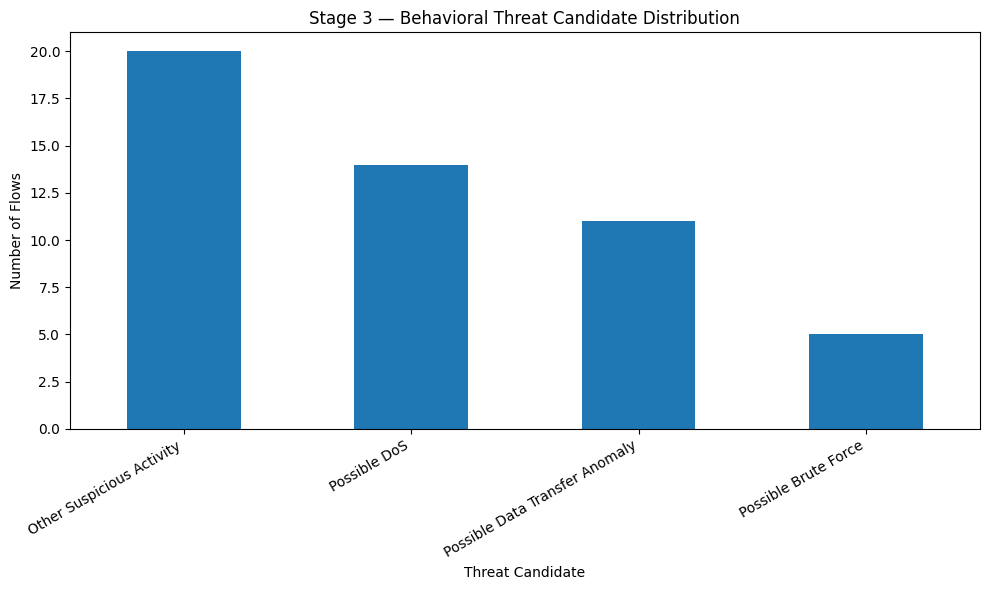

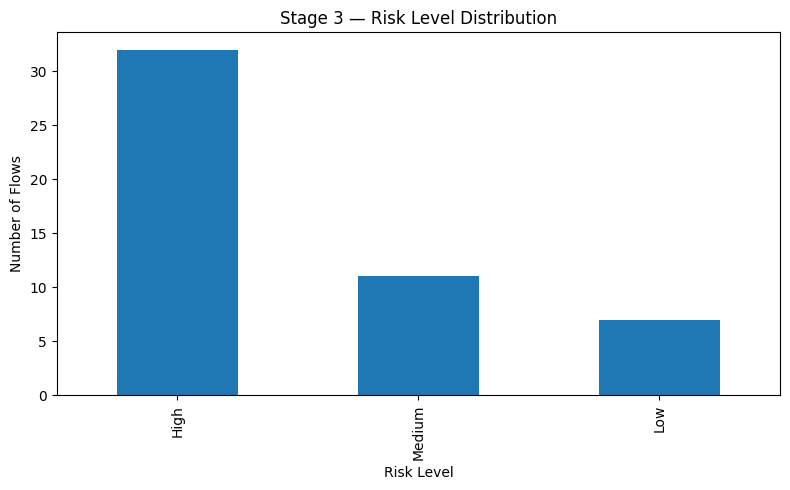

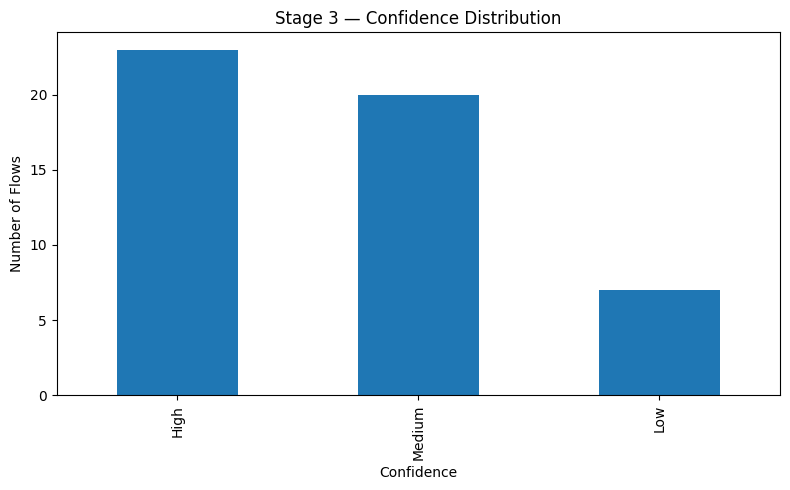

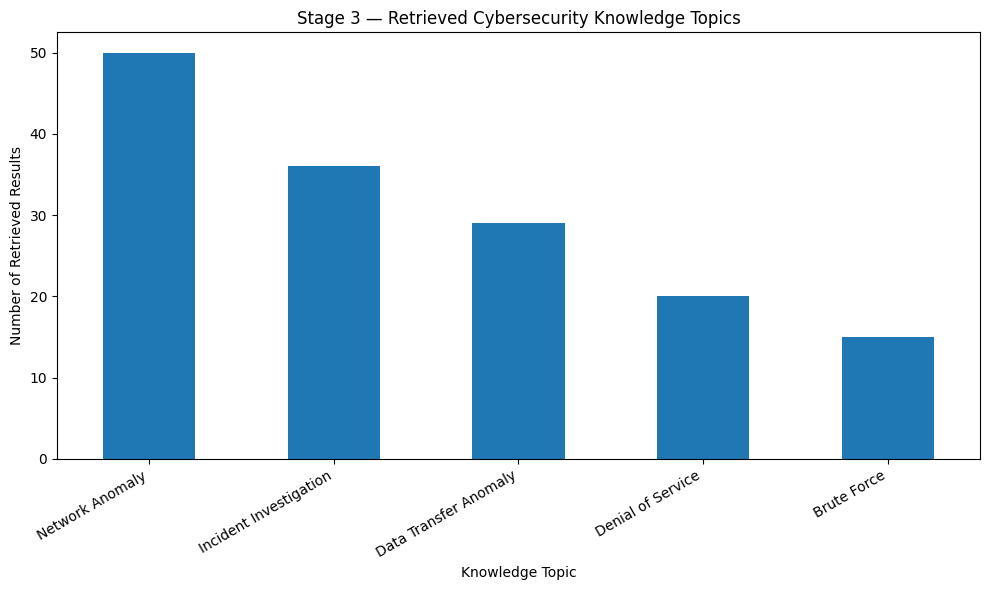

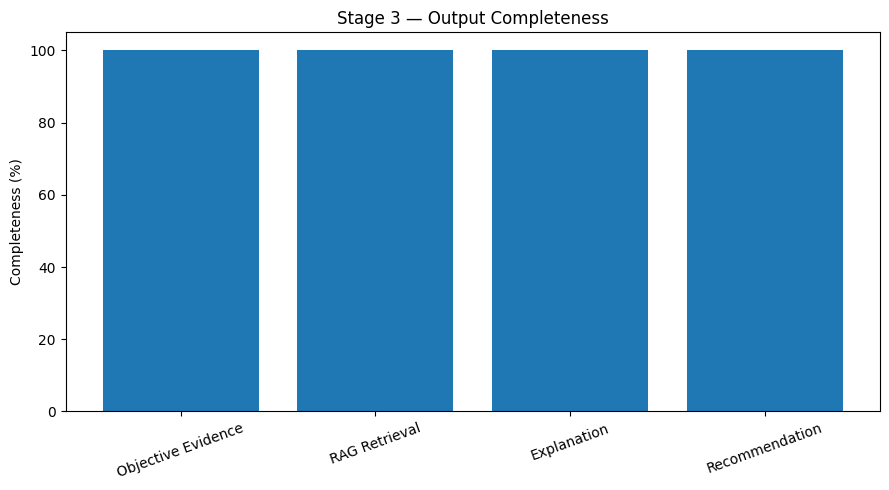

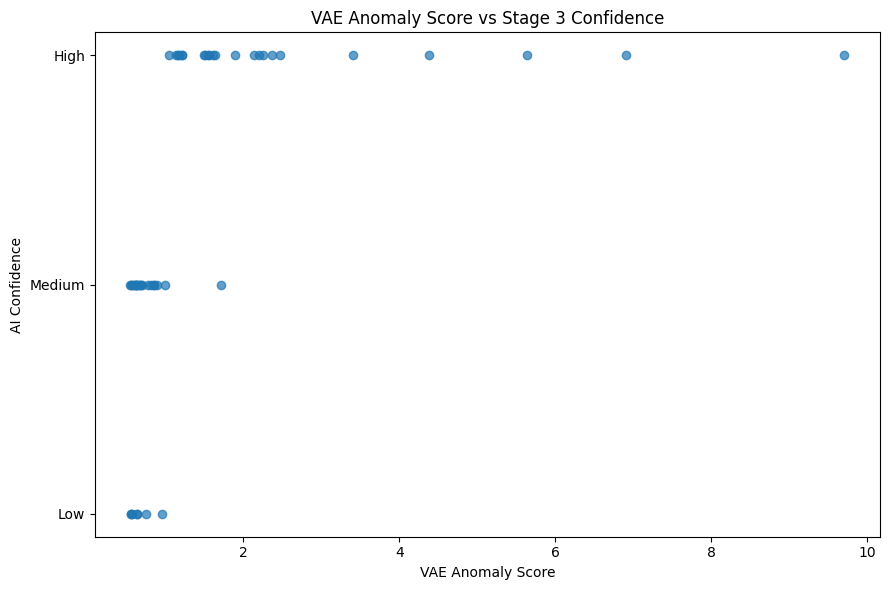

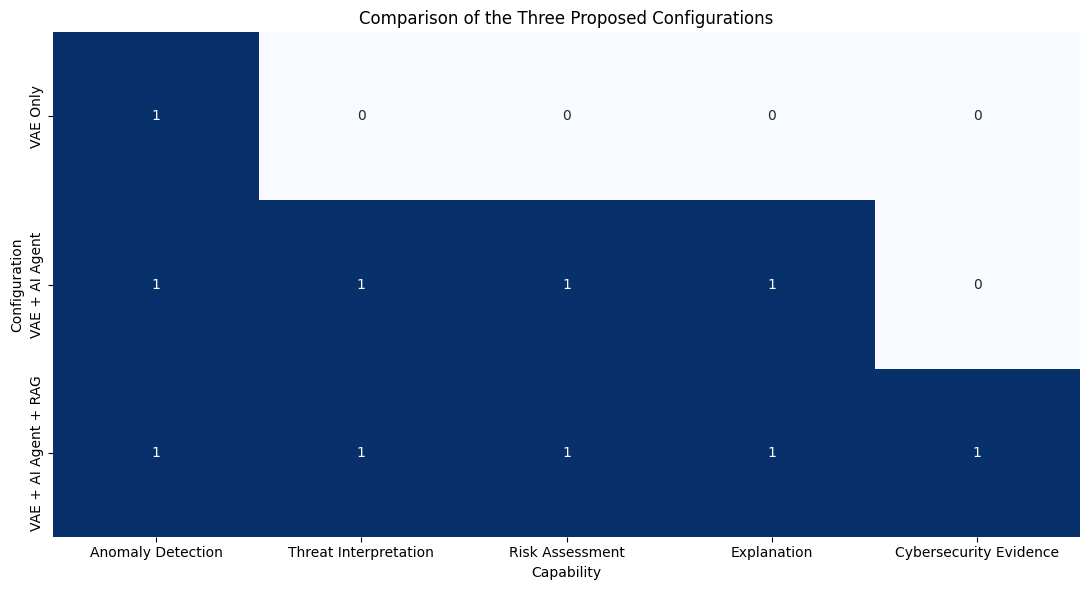


FINAL STAGE 3 EXAMPLES


,flow_number,vae_anomaly_score,selected_candidate,risk_level,confidence,retrieved_topics,objective_evidence,explanation,recommendation
0,1,1.169826,Possible Data Transfer Anomaly,High,High,Data Transfer Anomaly | Network Anomaly | Incident Investigation,Observed flow evidence: VAE anomaly score=1.1698; Flow_Duration=98325123.0000 (robust deviation=20.00); Fwd_Packets_Length_Total=11595.0000 (robust deviation=20.00); Fwd_Packet_Length_Max=7251.0000 (robust deviation=20.00); Fwd_Packet_Length_Mean=1932.5000 (robust deviation=20.00); Fwd_Packet_Le...,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with possible data transfer anomaly. The available flow-level evidence is not sufficient to confirm an attack.,"Investigate the source and destination of the transfer, review traffic volume and timing, and check for possible unauthorized data movement."
1,2,0.668652,Possible DoS,High,Medium,Data Transfer Anomaly | Network Anomaly | Incident Investigation,Observed flow evidence: VAE anomaly score=0.6687; Flow_Bytes/s=1500000.0000 (robust deviation=20.00); Flow_Packets/s=250000.0000 (robust deviation=20.00); Fwd_Packets/s=50000.0000 (robust deviation=20.00); Bwd_Packets/s=200000.0000 (robust deviation=20.00); Down/Up_Ratio=4.0000 (robust deviation...,"The high VAE anomaly score suggests potential DoS attacks due to unusually large flow sizes and packet deviations. The observed features indicate unusual bandwidth usage and packet length variations, which could point towards DoS attempts.",Conduct further analysis to confirm the presence of DoS attacks and take appropriate security measures.
2,3,0.672417,Possible DoS,High,Medium,Data Transfer Anomaly | Network Anomaly | Incident Investigation,Observed flow evidence: VAE anomaly score=0.6724; Flow_Bytes/s=1592592.5930 (robust deviation=20.00); Flow_Packets/s=111111.1111 (robust deviation=20.00); Bwd_Packets/s=74074.0700 (robust deviation=20.00); Fwd_Packets/s=37037.0350 (robust deviation=17.00); FIN_Flag_Count=1.0000 (robust deviation...,"The high VAE anomaly score suggests potential DoS attacks due to unusually large flow sizes and packet volumes. The robust deviation values indicate significant deviations from normal patterns, which could point towards DoS attempts.",Conduct further analysis to confirm the presence of DoS attacks and take appropriate security measures.
3,4,0.554347,Other Suspicious Activity,Low,Low,Incident Investigation | Network Anomaly | Denial of Service,Observed flow evidence: VAE anomaly score=0.5543; Flow_Bytes/s=31000000.0000 (robust deviation=20.00); Flow_Packets/s=2000000.0000 (robust deviation=20.00); Fwd_Packets/s=2000000.0000 (robust deviation=20.00); Fwd_PSH_Flags=1.0000 (robust deviation=5.68); SYN_Flag_Count=1.0000 (robust deviation=...,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with other suspicious activity. The available flow-level evidence is not sufficient to confirm an attack.,"Investigate the anomalous flow, review related network and host activity, validate the source and destination, and monitor for repeated suspicious behavior."
4,5,2.206593,Other Suspicious Activity,High,High,Incident Investigation | Network Anomaly | Denial of Service,Observed flow evidence: VAE anomaly score=2.2066; Fwd_IAT_Std=23367024.0000 (robust deviation=20.00); Fwd_IAT_Max=58156707.0000 (robust deviation=20.00); Bwd_IAT_Total=58406423.0000 (robust deviation=20.00); Bwd_IAT_Mean=58406424.0000 (robust deviation=20.00); Bwd_IAT_Max=58406423.0000 (robust d...,The flow was identified as anomalous by the VAE and shows behavioral characteristics consistent with other suspicious activity. The available flow-level evidence is not sufficient to confirm an attack.,"Investigate the anomalous flow, review related network and host activity, validate the source and destination, and monitor for repeated suspicious behavior."
5,6,0.687041,Other Suspicious Activity,Medium,Medium,Incident In


FINAL FILES
/content/FINAL_vae_ai_rag_results.csv
/content/FINAL_three_configuration_comparison.csv
/content/stage3_threat_distribution.png
/content/stage3_risk_distribution.png
/content/stage3_confidence_distribution.png
/content/stage3_rag_topics.png
/content/stage3_output_completeness.png
/content/stage3_score_vs_confidence.png
/content/three_configuration_comparison.png

PART 7 COMPLETE
Stage 3 RAG pipeline and final visualizations are complete.


In [ ]:
# ================================================================
# STAGE 3 — PART 7
# FINAL VISUALIZATIONS + EXPORT
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("STAGE 3 — PART 7: FINAL VISUALIZATIONS")
print("=" * 70)

# ------------------------------------------------
# LOAD RESULTS
# ------------------------------------------------

vae_results = pd.read_csv(
    "/content/vae_results.csv"
)

stage2_results = pd.read_csv(
    "/content/vae_ai_results.csv"
)

stage3_results = pd.read_csv(
    "/content/vae_ai_rag_final.csv"
)

# ================================================================
# VISUALIZATION 1
# STAGE 3 THREAT DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

stage3_results[
    "selected_candidate"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Stage 3 — Behavioral Threat Candidate Distribution"
)

plt.xlabel("Threat Candidate")
plt.ylabel("Number of Flows")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "/content/stage3_threat_distribution.png",
    dpi=300
)

plt.show()


# ================================================================
# VISUALIZATION 2
# STAGE 3 RISK DISTRIBUTION
# ================================================================

plt.figure(figsize=(8, 5))

stage3_results[
    "risk_level"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Stage 3 — Risk Level Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Flows")

plt.tight_layout()

plt.savefig(
    "/content/stage3_risk_distribution.png",
    dpi=300
)

plt.show()


# ================================================================
# VISUALIZATION 3
# STAGE 3 CONFIDENCE DISTRIBUTION
# ================================================================

plt.figure(figsize=(8, 5))

stage3_results[
    "confidence"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Stage 3 — Confidence Distribution"
)

plt.xlabel("Confidence")
plt.ylabel("Number of Flows")

plt.tight_layout()

plt.savefig(
    "/content/stage3_confidence_distribution.png",
    dpi=300
)

plt.show()


# ================================================================
# VISUALIZATION 4
# RAG RETRIEVED TOPICS
# ================================================================

topic_counts = {}

for topics in stage3_results[
    "retrieved_topics"
].fillna(""):

    for topic in str(topics).split("|"):

        topic = topic.strip()

        if topic:

            topic_counts[topic] = (
                topic_counts.get(topic, 0) + 1
            )

topic_series = pd.Series(
    topic_counts
).sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

topic_series.plot(
    kind="bar"
)

plt.title(
    "Stage 3 — Retrieved Cybersecurity Knowledge Topics"
)

plt.xlabel("Knowledge Topic")
plt.ylabel("Number of Retrieved Results")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "/content/stage3_rag_topics.png",
    dpi=300
)

plt.show()


# ================================================================
# VISUALIZATION 5
# OUTPUT COMPLETENESS
# ================================================================

completeness = {

    "Objective Evidence":
        stage3_results[
            "objective_evidence"
        ].fillna("").astype(str).str.strip().ne("").mean() * 100,

    "RAG Retrieval":
        stage3_results[
            "retrieved_topics"
        ].fillna("").astype(str).str.strip().ne("").mean() * 100,

    "Explanation":
        stage3_results[
            "explanation"
        ].fillna("").astype(str).str.strip().ne("").mean() * 100,

    "Recommendation":
        stage3_results[
            "recommendation"
        ].fillna("").astype(str).str.strip().ne("").mean() * 100
}

plt.figure(figsize=(9, 5))

plt.bar(
    completeness.keys(),
    completeness.values()
)

plt.title(
    "Stage 3 — Output Completeness"
)

plt.ylabel(
    "Completeness (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    "/content/stage3_output_completeness.png",
    dpi=300
)

plt.show()


# ================================================================
# VISUALIZATION 6
# VAE ANOMALY SCORE VS STAGE 3 CONFIDENCE
# ================================================================

confidence_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

plot_data = stage3_results.copy()

plot_data[
    "confidence_numeric"
] = plot_data[
    "confidence"
].map(
    confidence_map
)

plt.figure(figsize=(9, 6))

plt.scatter(
    plot_data[
        "vae_anomaly_score"
    ],
    plot_data[
        "confidence_numeric"
    ],
    alpha=0.7
)

plt.xlabel(
    "VAE Anomaly Score"
)

plt.ylabel(
    "AI Confidence"
)

plt.yticks(
    [1, 2, 3],
    ["Low", "Medium", "High"]
)

plt.title(
    "VAE Anomaly Score vs Stage 3 Confidence"
)

plt.tight_layout()

plt.savefig(
    "/content/stage3_score_vs_confidence.png",
    dpi=300
)

plt.show()


# ================================================================
# VISUALIZATION 7
# THREE-CONFIGURATION CONCEPTUAL COMPARISON
# ================================================================

configuration_features = pd.DataFrame({

    "Configuration": [
        "VAE Only",
        "VAE + AI Agent",
        "VAE + AI Agent + RAG"
    ],

    "Anomaly Detection": [
        1,
        1,
        1
    ],

    "Threat Interpretation": [
        0,
        1,
        1
    ],

    "Risk Assessment": [
        0,
        1,
        1
    ],

    "Explanation": [
        0,
        1,
        1
    ],

    "Cybersecurity Evidence": [
        0,
        0,
        1
    ]
})

configuration_features_plot = (
    configuration_features
    .set_index("Configuration")
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    configuration_features_plot,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Comparison of the Three Proposed Configurations"
)

plt.xlabel("Capability")
plt.ylabel("Configuration")

plt.tight_layout()

plt.savefig(
    "/content/three_configuration_comparison.png",
    dpi=300
)

plt.show()


# ================================================================
# FINAL EXAMPLE TABLE
# ================================================================

print("\n" + "=" * 70)
print("FINAL STAGE 3 EXAMPLES")
print("=" * 70)

display(
    stage3_results[
        [
            "flow_number",
            "vae_anomaly_score",
            "selected_candidate",
            "risk_level",
            "confidence",
            "retrieved_topics",
            "objective_evidence",
            "explanation",
            "recommendation"
        ]
    ].head(10)
)


# ================================================================
# FINAL EXPORTS
# ================================================================

stage3_results.to_csv(
    "/content/FINAL_vae_ai_rag_results.csv",
    index=False
)

configuration_features.to_csv(
    "/content/FINAL_three_configuration_comparison.csv",
    index=False
)

print("\n" + "=" * 70)
print("FINAL FILES")
print("=" * 70)

print(
    "/content/FINAL_vae_ai_rag_results.csv"
)

print(
    "/content/FINAL_three_configuration_comparison.csv"
)

print(
    "/content/stage3_threat_distribution.png"
)

print(
    "/content/stage3_risk_distribution.png"
)

print(
    "/content/stage3_confidence_distribution.png"
)

print(
    "/content/stage3_rag_topics.png"
)

print(
    "/content/stage3_output_completeness.png"
)

print(
    "/content/stage3_score_vs_confidence.png"
)

print(
    "/content/three_configuration_comparison.png"
)

print("\n" + "=" * 70)
print("PART 7 COMPLETE")
print("=" * 70)

print(
    "Stage 3 RAG pipeline and final visualizations are complete."
)

In [ ]:
three stages comparison

PART 8 — FINAL THREE-STAGE COMPARISON

Files loaded:
VAE: (100000, 72)
Stage 2: (50, 13)
Stage 3: (50, 17)

STAGE 1 — VAE DETECTION PERFORMANCE
Accuracy  : 0.374
Precision : 1.000
Recall    : 0.374
F1 Score  : 0.545

OUTPUT COMPLETENESS
                   Stage 1 — VAE Only  Stage 2 — VAE + AI  \
Anomaly Detection                 100               100.0   
Anomaly Score                     100               100.0   
Confidence                          0               100.0   
Evidence                            0               100.0   
Explanation                         0               100.0   
Recommendation                      0               100.0   

                   Stage 3 — VAE + AI + RAG  
Anomaly Detection                     100.0  
Anomaly Score                         100.0  
Confidence                            100.0  
Evidence                              100.0  
Explanation                           100.0  
Recommendation                        100.0  

DETECTION PE

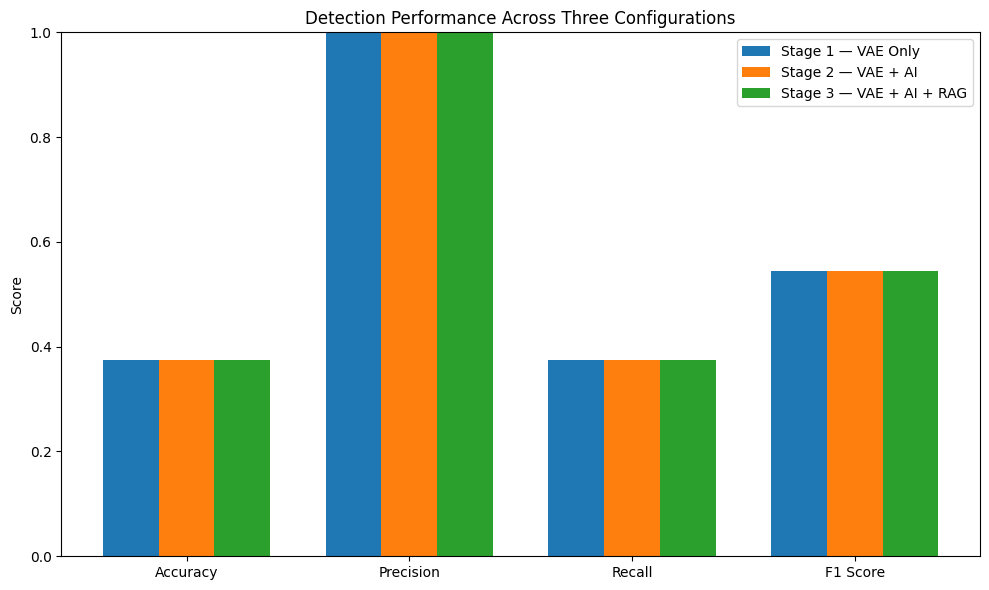

<Figure size 1200x600 with 0 Axes>

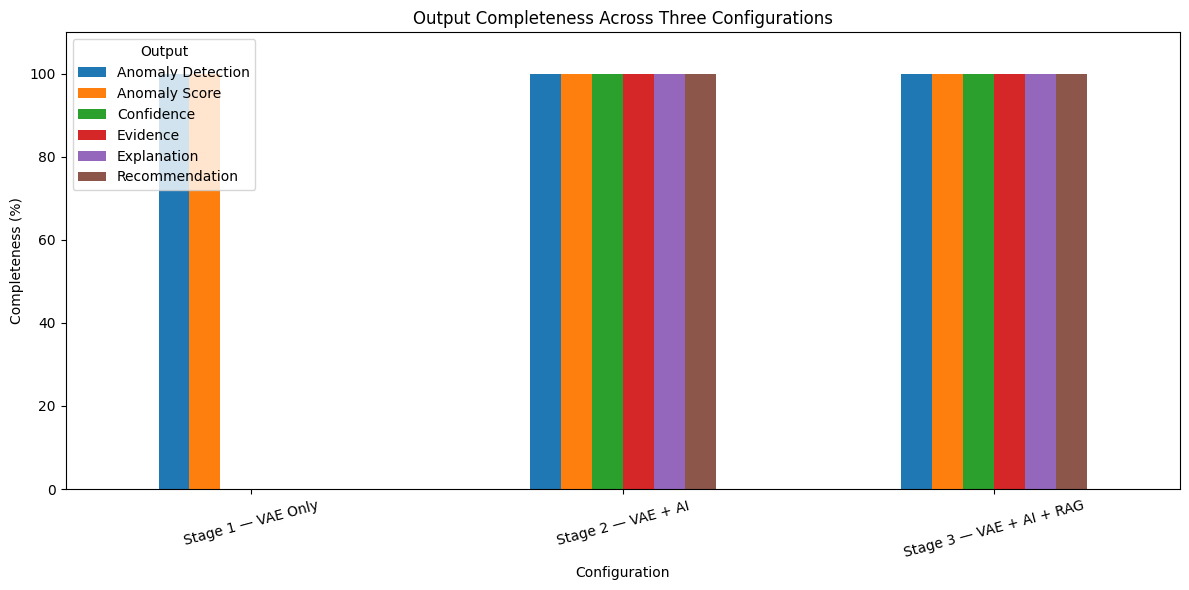

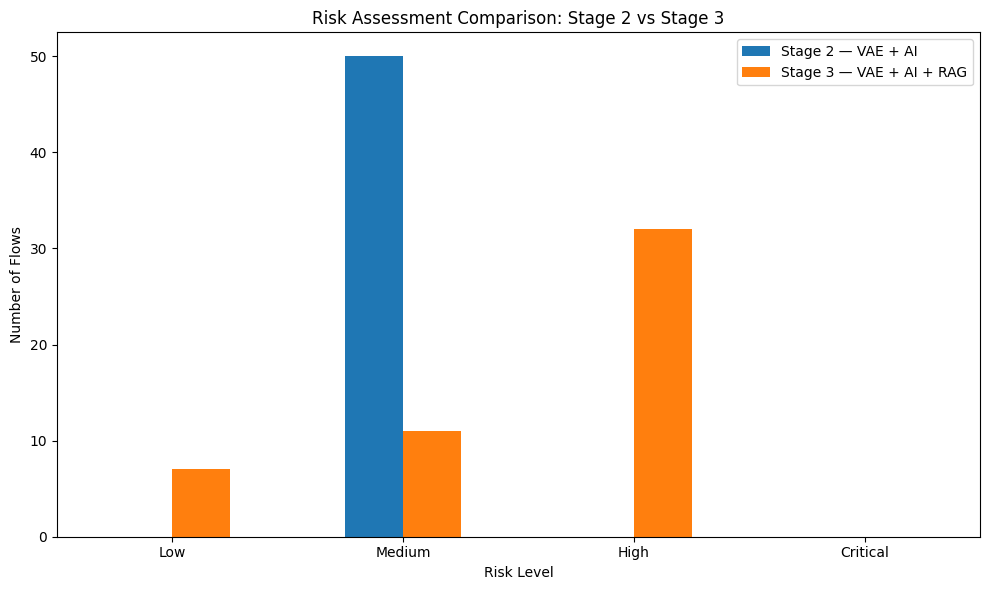

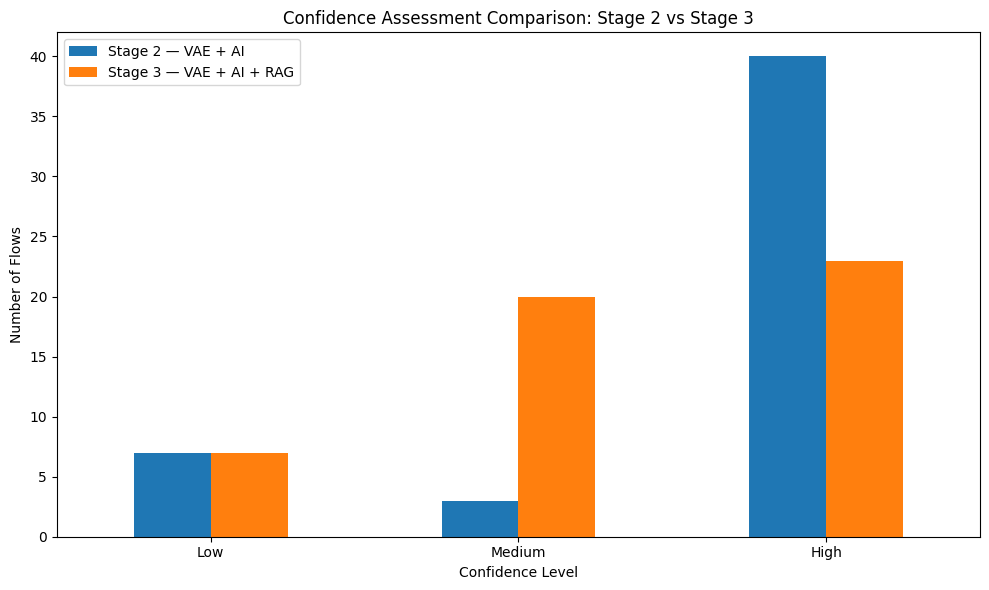

<Figure size 1200x600 with 0 Axes>

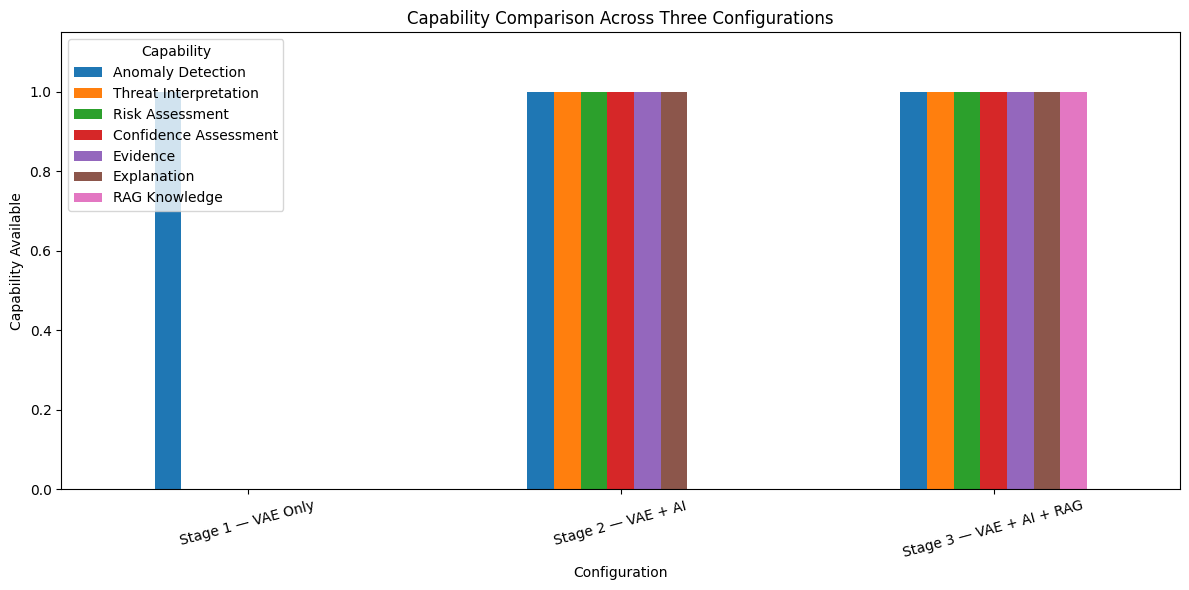


FINAL THREE-CONFIGURATION COMPARISON
                 Configuration Detection Threat_Interpretation Risk_Assessment Evidence Explanation Recommendation RAG  Accuracy       F1
            Stage 1 — VAE Only       Yes                    No              No       No          No             No  No   0.37436 0.544777
      Stage 2 — VAE + AI Agent       Yes                   Yes             Yes      Yes         Yes            Yes  No   0.37436 0.544777
Stage 3 — VAE + AI Agent + RAG       Yes                   Yes             Yes      Yes         Yes            Yes Yes   0.37436 0.544777

PART 8 COMPLETE

Saved files:
/content/comparison_detection_performance.png
/content/comparison_output_completeness.png
/content/comparison_risk_levels.png
/content/comparison_confidence_levels.png
/content/comparison_capabilities.png
/content/final_detection_comparison.csv
/content/final_risk_comparison.csv
/content/final_confidence_comparison.csv
/content/final_three_configuration_comparison.csv
/content

In [ ]:
# ============================================================
# PART 8 — FINAL STAGE 1 vs STAGE 2 vs STAGE 3 COMPARISON
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("PART 8 — FINAL THREE-STAGE COMPARISON")
print("=" * 70)


# ============================================================
# 1. LOAD RESULTS
# ============================================================

vae_results = pd.read_csv("/content/vae_results.csv")
stage2_results = pd.read_csv("/content/vae_ai_results.csv")
stage3_results = pd.read_csv("/content/vae_ai_rag_final.csv")

print("\nFiles loaded:")
print("VAE:", vae_results.shape)
print("Stage 2:", stage2_results.shape)
print("Stage 3:", stage3_results.shape)


# ============================================================
# 2. STAGE 1 DETECTION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Actual label
actual = vae_results["actual_label"].astype(str).str.upper()

y_true = (actual != "BENIGN").astype(int)
y_pred = vae_results["vae_prediction"].astype(int)

stage1_accuracy = accuracy_score(y_true, y_pred)
stage1_precision = precision_score(y_true, y_pred, zero_division=0)
stage1_recall = recall_score(y_true, y_pred, zero_division=0)
stage1_f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n" + "=" * 70)
print("STAGE 1 — VAE DETECTION PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {stage1_accuracy:.3f}")
print(f"Precision : {stage1_precision:.3f}")
print(f"Recall    : {stage1_recall:.3f}")
print(f"F1 Score  : {stage1_f1:.3f}")


# ============================================================
# 3. INTERPRETATION / OUTPUT METRICS
# ============================================================

def completeness(df, column):
    if column not in df.columns:
        return 0.0

    values = (
        df[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    invalid = {
        "",
        "nan",
        "none",
        "unknown",
        "unknown/uncertain",
        "n/a",
        "na",
        "not available",
        "not provided"
    }

    return (~values.isin(invalid)).mean() * 100


stage2_completeness = {
    "Threat": completeness(stage2_results, "threat_type"),
    "Risk": completeness(stage2_results, "risk_level"),
    "Confidence": completeness(stage2_results, "confidence"),
    "Evidence": completeness(stage2_results, "evidence"),
    "Explanation": completeness(stage2_results, "explanation"),
    "Recommendation": completeness(stage2_results, "recommendation")
}

stage3_completeness = {
    "Threat": completeness(stage3_results, "selected_candidate"),
    "Risk": completeness(stage3_results, "risk_level"),
    "Confidence": completeness(stage3_results, "confidence"),
    "Evidence": completeness(stage3_results, "objective_evidence"),
    "Explanation": completeness(stage3_results, "explanation"),
    "Recommendation": completeness(stage3_results, "recommendation")
}

print("\n" + "=" * 70)
print("OUTPUT COMPLETENESS")
print("=" * 70)

comparison_completeness = pd.DataFrame({
    "Stage 1 — VAE Only": [100, 100, 0, 0, 0, 0],
    "Stage 2 — VAE + AI": [
        stage2_completeness["Threat"],
        stage2_completeness["Risk"],
        stage2_completeness["Confidence"],
        stage2_completeness["Evidence"],
        stage2_completeness["Explanation"],
        stage2_completeness["Recommendation"]
    ],
    "Stage 3 — VAE + AI + RAG": [
        stage3_completeness["Threat"],
        stage3_completeness["Risk"],
        stage3_completeness["Confidence"],
        stage3_completeness["Evidence"],
        stage3_completeness["Explanation"],
        stage3_completeness["Recommendation"]
    ]
}, index=[
    "Anomaly Detection",
    "Anomaly Score",
    "Confidence",
    "Evidence",
    "Explanation",
    "Recommendation"
])

print(comparison_completeness)


# ============================================================
# 4. DETECTION METRICS TABLE
# ============================================================

detection_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Stage 1 — VAE Only": [
        stage1_accuracy,
        stage1_precision,
        stage1_recall,
        stage1_f1
    ],
    "Stage 2 — VAE + AI": [
        stage1_accuracy,
        stage1_precision,
        stage1_recall,
        stage1_f1
    ],
    "Stage 3 — VAE + AI + RAG": [
        stage1_accuracy,
        stage1_precision,
        stage1_recall,
        stage1_f1
    ]
})

print("\n" + "=" * 70)
print("DETECTION PERFORMANCE COMPARISON")
print("=" * 70)

print(detection_comparison.to_string(index=False))


# ============================================================
# 5. RISK DISTRIBUTION COMPARISON
# ============================================================

stage2_risk = (
    stage2_results["risk_level"]
    .value_counts()
    .to_dict()
)

stage3_risk = (
    stage3_results["risk_level"]
    .value_counts()
    .to_dict()
)

risk_comparison = pd.DataFrame({
    "Stage 2 — VAE + AI": [
        stage2_risk.get("Low", 0),
        stage2_risk.get("Medium", 0),
        stage2_risk.get("High", 0),
        stage2_risk.get("Critical", 0)
    ],
    "Stage 3 — VAE + AI + RAG": [
        stage3_risk.get("Low", 0),
        stage3_risk.get("Medium", 0),
        stage3_risk.get("High", 0),
        stage3_risk.get("Critical", 0)
    ]
}, index=["Low", "Medium", "High", "Critical"])

print("\n" + "=" * 70)
print("RISK DISTRIBUTION COMPARISON")
print("=" * 70)

print(risk_comparison)


# ============================================================
# 6. CONFIDENCE DISTRIBUTION COMPARISON
# ============================================================

stage2_conf = (
    stage2_results["confidence"]
    .value_counts()
    .to_dict()
)

stage3_conf = (
    stage3_results["confidence"]
    .value_counts()
    .to_dict()
)

confidence_comparison = pd.DataFrame({
    "Stage 2 — VAE + AI": [
        stage2_conf.get("Low", 0),
        stage2_conf.get("Medium", 0),
        stage2_conf.get("High", 0)
    ],
    "Stage 3 — VAE + AI + RAG": [
        stage3_conf.get("Low", 0),
        stage3_conf.get("Medium", 0),
        stage3_conf.get("High", 0)
    ]
}, index=["Low", "Medium", "High"])

print("\n" + "=" * 70)
print("CONFIDENCE DISTRIBUTION COMPARISON")
print("=" * 70)

print(confidence_comparison)


# ============================================================
# 7. GRAPH 1 — DETECTION PERFORMANCE
# ============================================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    detection_comparison["Stage 1 — VAE Only"],
    width,
    label="Stage 1 — VAE Only"
)

plt.bar(
    x,
    detection_comparison["Stage 2 — VAE + AI"],
    width,
    label="Stage 2 — VAE + AI"
)

plt.bar(
    x + width,
    detection_comparison["Stage 3 — VAE + AI + RAG"],
    width,
    label="Stage 3 — VAE + AI + RAG"
)

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Detection Performance Across Three Configurations")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/comparison_detection_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. GRAPH 2 — OUTPUT COMPLETENESS
# ============================================================

plot_data = comparison_completeness.T

plt.figure(figsize=(12, 6))

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Completeness (%)")
plt.xlabel("Configuration")
plt.title("Output Completeness Across Three Configurations")
plt.ylim(0, 110)
plt.xticks(rotation=15)
plt.legend(title="Output")
plt.tight_layout()

plt.savefig(
    "/content/comparison_output_completeness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. GRAPH 3 — RISK COMPARISON
# ============================================================

risk_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Number of Flows")
plt.xlabel("Risk Level")
plt.title("Risk Assessment Comparison: Stage 2 vs Stage 3")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/comparison_risk_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. GRAPH 4 — CONFIDENCE COMPARISON
# ============================================================

confidence_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Number of Flows")
plt.xlabel("Confidence Level")
plt.title("Confidence Assessment Comparison: Stage 2 vs Stage 3")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/comparison_confidence_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. GRAPH 5 — CAPABILITY COMPARISON
# ============================================================

capability_data = pd.DataFrame({
    "Stage 1 — VAE Only": [
        1, 0, 0, 0, 0, 0, 0
    ],
    "Stage 2 — VAE + AI": [
        1, 1, 1, 1, 1, 1, 0
    ],
    "Stage 3 — VAE + AI + RAG": [
        1, 1, 1, 1, 1, 1, 1
    ]
}, index=[
    "Anomaly Detection",
    "Threat Interpretation",
    "Risk Assessment",
    "Confidence Assessment",
    "Evidence",
    "Explanation",
    "RAG Knowledge"
])

plt.figure(figsize=(12, 6))

capability_data.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Capability Available")
plt.xlabel("Configuration")
plt.title("Capability Comparison Across Three Configurations")
plt.ylim(0, 1.15)
plt.xticks(rotation=15)
plt.legend(title="Capability")
plt.tight_layout()

plt.savefig(
    "/content/comparison_capabilities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. FINAL SUMMARY TABLE
# ============================================================

final_comparison = pd.DataFrame({
    "Configuration": [
        "Stage 1 — VAE Only",
        "Stage 2 — VAE + AI Agent",
        "Stage 3 — VAE + AI Agent + RAG"
    ],
    "Detection": [
        "Yes",
        "Yes",
        "Yes"
    ],
    "Threat_Interpretation": [
        "No",
        "Yes",
        "Yes"
    ],
    "Risk_Assessment": [
        "No",
        "Yes",
        "Yes"
    ],
    "Evidence": [
        "No",
        "Yes",
        "Yes"
    ],
    "Explanation": [
        "No",
        "Yes",
        "Yes"
    ],
    "Recommendation": [
        "No",
        "Yes",
        "Yes"
    ],
    "RAG": [
        "No",
        "No",
        "Yes"
    ],
    "Accuracy": [
        stage1_accuracy,
        stage1_accuracy,
        stage1_accuracy
    ],
    "F1": [
        stage1_f1,
        stage1_f1,
        stage1_f1
    ]
})

print("\n" + "=" * 70)
print("FINAL THREE-CONFIGURATION COMPARISON")
print("=" * 70)

print(final_comparison.to_string(index=False))


# ============================================================
# 13. SAVE TABLES
# ============================================================

detection_comparison.to_csv(
    "/content/final_detection_comparison.csv",
    index=False
)

risk_comparison.to_csv(
    "/content/final_risk_comparison.csv"
)

confidence_comparison.to_csv(
    "/content/final_confidence_comparison.csv"
)

final_comparison.to_csv(
    "/content/final_three_configuration_comparison.csv",
    index=False
)

comparison_completeness.to_csv(
    "/content/final_output_completeness_comparison.csv"
)


print("\n" + "=" * 70)
print("PART 8 COMPLETE")
print("=" * 70)

print("\nSaved files:")
print("/content/comparison_detection_performance.png")
print("/content/comparison_output_completeness.png")
print("/content/comparison_risk_levels.png")
print("/content/comparison_confidence_levels.png")
print("/content/comparison_capabilities.png")

print("/content/final_detection_comparison.csv")
print("/content/final_risk_comparison.csv")
print("/content/final_confidence_comparison.csv")
print("/content/final_three_configuration_comparison.csv")
print("/content/final_output_completeness_comparison.csv")